# Random Forest with Summed 2m 4.7

In [1]:
import sys
print(sys.executable)
import matplotlib
print(matplotlib.__file__)

/usr/local/bin/python3
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/matplotlib/__init__.py


In [27]:
# imports
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np

In [2]:
# Loading the Dataset
CACHE_DIR = Path('../Data/Parquet')
CACHE_DIR.mkdir(exist_ok=True)

def load_or_cache(csv_path, parquet_path, usecols=None):
    parquet_path = Path(parquet_path)

    if parquet_path.exists():
        print(f"Loading cached: {parquet_path}")
        return pd.read_parquet(parquet_path)

    print(f"Reading CSV: {csv_path}")
    df = pd.read_csv(
        csv_path,
        usecols=usecols,
        low_memory=False
    )

    # Normalize object columns so Parquet doesn't choke
    obj_cols = df.select_dtypes(include="object").columns
    if len(obj_cols) > 0:
        df[obj_cols] = df[obj_cols].astype("string")

    print(f"Caching → {parquet_path}")
    df.to_parquet(parquet_path)

    return df

enhanced_df = load_or_cache(
    '../Data/Enhanced.csv',
    CACHE_DIR / 'New_estchlsummed.parquet'
)

Loading cached: ../Data/Parquet/New_estchlsummed.parquet


In [30]:
# Checking if everything is numeric
for col in enhanced_df.columns:
    if enhanced_df[col].dtype != 'numeric':
        #print(f"Column '{col}' is of type '{enhanced_df[col].dtype}'.")
        enhanced_df[col] = pd.to_numeric(enhanced_df[col], errors='coerce')

#print(f"Column '{col}' is of type '{enhanced_df[col].dtype}'.")
# Checking for rows and columns, shape of the dataset
print(f"Dataset shape: {enhanced_df.shape}")

Dataset shape: (1971, 43)


In [31]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
import joblib

In [32]:
print(enhanced_df.columns)

Index(['ORD_OCC', 'CAST_ID', 'DATE_TIME_UTC', 'DATE_TIME_PST', 'LAT_DEC',
       'LON_DEC', 'STA_ID', 'LINE', 'STA', 'DEPTH', 'PRESSURE',
       'ESTCHL_CRUISECORR', 'ESTCHL_STACORR', 'BAT', 'XMISS', 'SPAR', 'PAR',
       'CHL_A', 'PHAEO', 'CAST_COUNT', 'PHOTIC_ZONE', 'XMISS_SUMMED',
       'CHL_A_SUMMED', 'PHAEO_SUMMED', 'ESTCHL_SUMMED', 'Cruise_ID',
       'Cruz_Sta', 'Cast_ID', 'Sta_ID', 'Distance', 'Date', 'Time', 'Lat_Dec',
       'Lon_Dec', 'Ac_Line', 'Bottom_D', 'Secchi', 'IntChl', 'IntC14',
       'TimeZone', 'Visibility', 'K_PAR', 'K_PAR_SLOPE'],
      dtype='str')


Fitting 5 folds for each of 324 candidates, totalling 1620 fits
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   1.0s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   1.0s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   1.2s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   1.1s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   1.2s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=500; total time=   2.4s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=500; total time=   2.7s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=

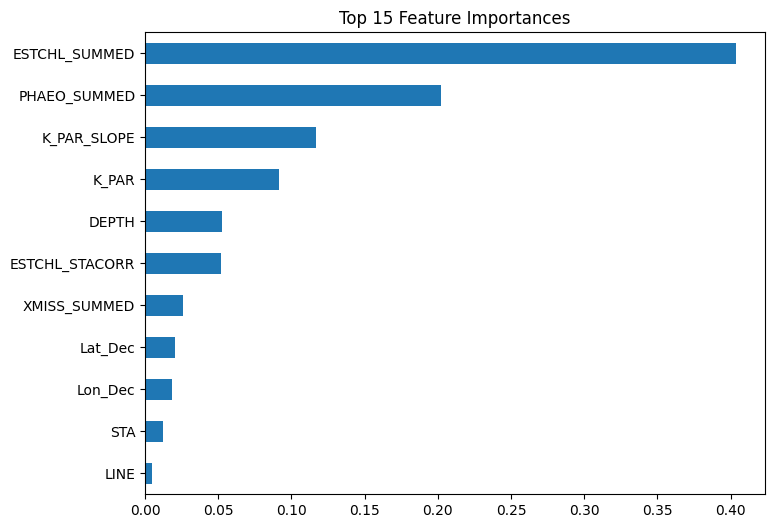

In [37]:
exclude_cols = ['ORD_OCC', 'CAST_ID', 'DATE_TIME_UTC', 'DATE_TIME_PST', 'LAT_DEC',
       'LON_DEC', 'STA_ID', 'PRESSURE',
       'ESTCHL_CRUISECORR', 'BAT', 'XMISS', 'SPAR', 'PAR',
       'CHL_A', 'PHAEO', 'CAST_COUNT', 'PHOTIC_ZONE', 
       'Cruise_ID', 'Cruz_Sta', 'Cast_ID', 'Sta_ID',
       'Distance', 'Date', 'Time', 'Ac_Line', 'Bottom_D',
       'IntChl', 'IntC14', 'TimeZone', 'Visibility', 'CHL_A_SUMMED'
]

# Feature columns for modeling, not in exclude_cols
feature_cols = [col for col in enhanced_df.columns if col not in exclude_cols]

models_dir = Path("../Models")
models_dir.mkdir(exist_ok=True)

target_col = "Secchi"

feature_cols = [col for col in enhanced_df.columns if col not in exclude_cols + [target_col]]

X = enhanced_df[feature_cols].copy()
y = enhanced_df[target_col].copy()

# Drop rows with NA
mask = X.notna().all(axis=1) & y.notna()
X = X[mask]
y = y[mask]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

rf = RandomForestRegressor(random_state=42)

param_grid = {
    "n_estimators": [200, 500, 1000],
    "max_features": ["sqrt", 0.3, 0.5],   # m_try
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",  # better than MSE
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_

print("Best Parameters:")
print(grid_search.best_params_)

y_pred = best_rf.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"Test RMSE: {rmse:.4f}")
print(f"Test R²: {r2:.4f}")

model_path = models_dir / "summed_47enhanced_random_forest_model.pkl"
joblib.dump(best_rf, model_path)
print(f"Model saved to {model_path}")

importances = pd.Series(best_rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(8,6))
importances.head(15).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importances")
plt.show()

# Random Forest without extra hyperparameters

PREPARING DATA

Number of features: 3
Features: ['XMISS_SUMMED', 'ESTCHL_SUMMED', 'K_PAR']

Final sample size: 1971

TRAIN/TEST SPLIT

Training set: 1576 samples
Test set:     395 samples
Number of features: 3

TRAINING RANDOM FOREST

Performing 5-Fold Cross-Validation...

5-Fold Cross-Validation RMSE (on training data):
  Mean: 4.3746
  Std:  0.2235
  Folds: [4.53155024 4.24538677 4.24317017 4.73118775 4.12172216]

5-Fold Cross-Validation R² (on training data):
  Mean: 0.7479
  Std:  0.0193
  Folds: [0.71332057 0.76766797 0.75109304 0.7437061  0.76360902]

Training final model on all training data...

TRAINING SET PERFORMANCE

RMSE: 2.3212
MAE:  1.6654
R²:   0.9294

TEST SET PERFORMANCE

RMSE: 4.4631
MAE:  3.4130
R²:   0.7433

FEATURE IMPORTANCE

Top 15 Most Important Features:
      feature  importance
ESTCHL_SUMMED    0.801724
        K_PAR    0.123472
 XMISS_SUMMED    0.074804

Feature importance saved to: ../Models/feature_importance.csv

SAVING MODEL

Model saved to: ../Models/su

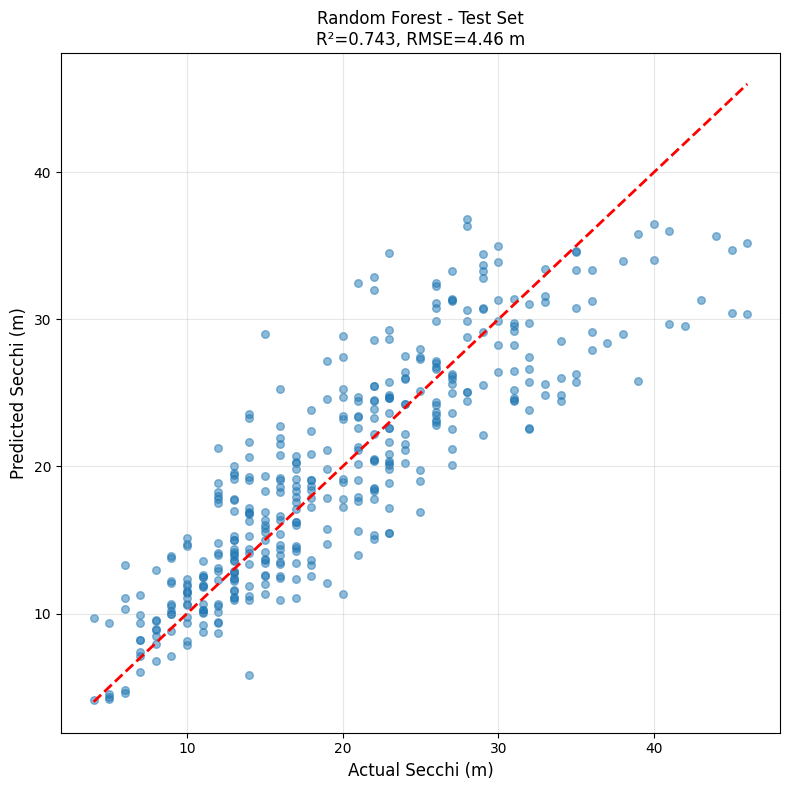

Saved: feature_importance.png


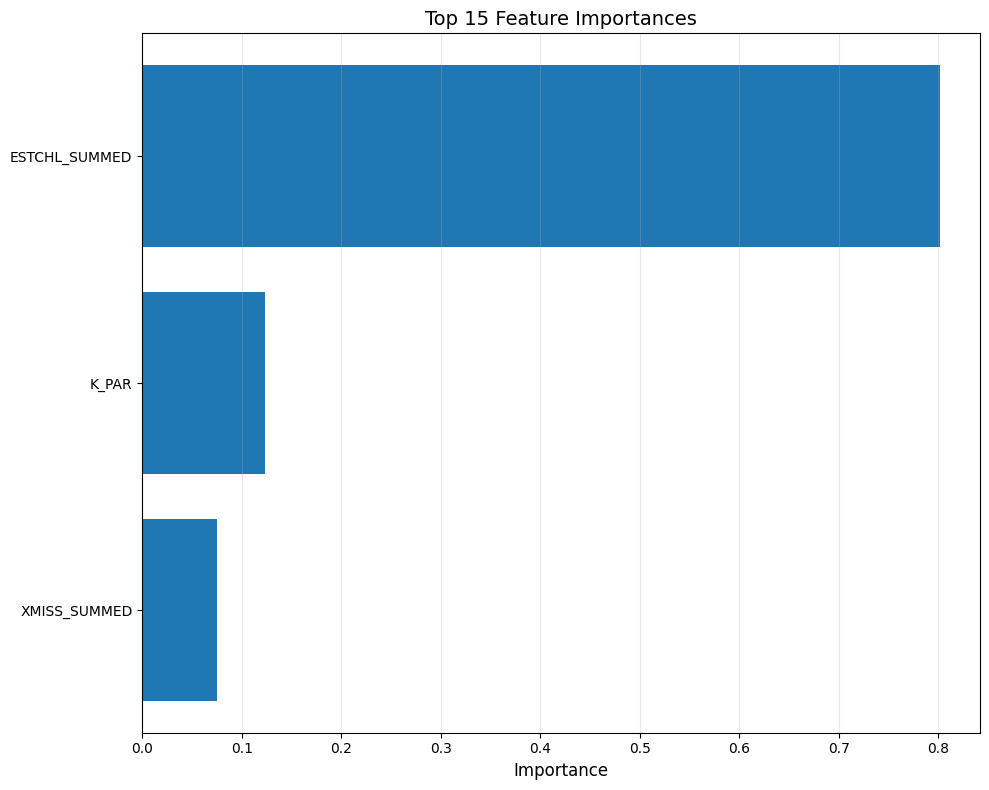

Saved: residual_plot.png


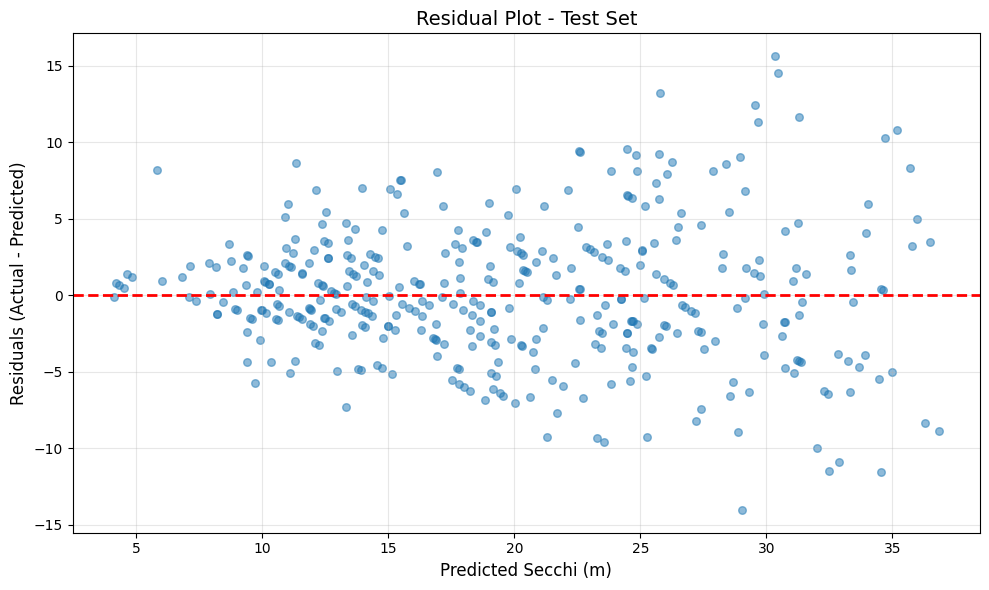

Saved: cv_scores.png


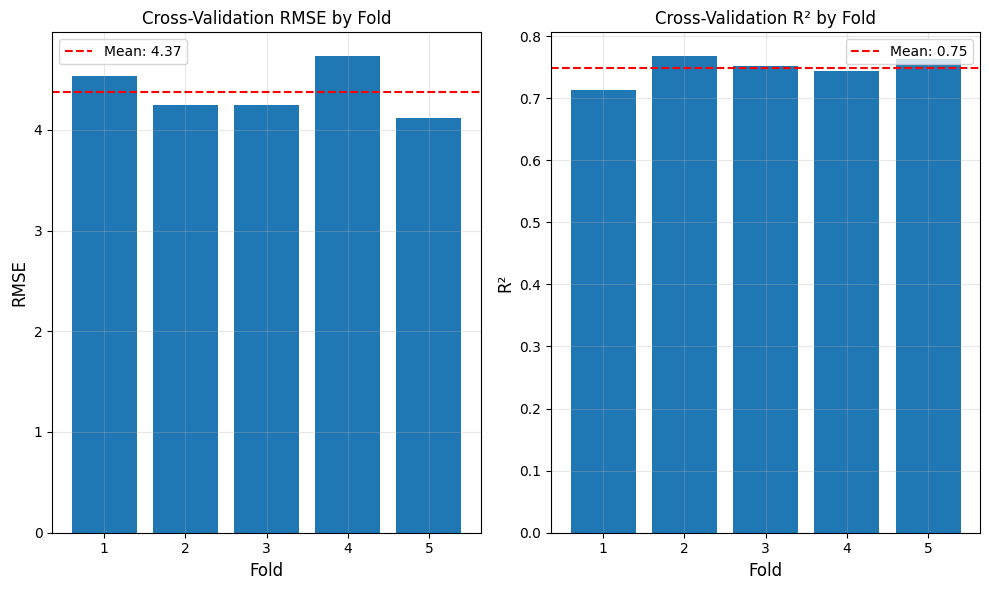


SUMMARY

Cross-Validation (5-fold):
  Mean RMSE: 4.3746 ± 0.2235
  Mean R²:   0.7479 ± 0.0193

Training Set:
  RMSE: 2.3212
  R²:   0.9294

Test Set:
  RMSE: 4.4631
  R²:   0.7433

Model saved to: ../Models/summed_47enhanced_random_forest_model.joblib
Visualizations saved to: ../Models

ANALYSIS COMPLETE!


In [3]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import joblib
import matplotlib.pyplot as plt

# ============================================================================
# SETUP
# ============================================================================

exclude_cols = ['ORD_OCC', 'CAST_ID', 'DATE_TIME_UTC', 'DATE_TIME_PST', 'LAT_DEC',
       'LON_DEC', 'STA_ID', 'PRESSURE',
       'ESTCHL_CRUISECORR', 'BAT', 'XMISS', 'SPAR', 'PAR',
       'CHL_A', 'PHAEO', 'CAST_COUNT', 'PHOTIC_ZONE', 
       'Cruise_ID', 'Cruz_Sta', 'Cast_ID', 'Sta_ID',
       'Distance', 'Date', 'Time', 'Ac_Line', 'Bottom_D',
       'IntChl', 'IntC14', 'TimeZone', 'Visibility', 'CHL_A_SUMMED'
]

target_col = "Secchi"

models_dir = Path("../Models")
models_dir.mkdir(exist_ok=True)

# ============================================================================
# PREPARE DATA
# ============================================================================

print("="*80)
print("PREPARING DATA")
print("="*80)

# Feature columns
feature_cols = ['XMISS_SUMMED', 'ESTCHL_SUMMED', 'K_PAR']  # Only using the summed version of XMISS for this model, 

print(f"\nNumber of features: {len(feature_cols)}")
print(f"Features: {feature_cols}")

X = enhanced_df[feature_cols].copy()
y = enhanced_df[target_col].copy()

# Drop rows with NA
mask = X.notna().all(axis=1) & y.notna()
X = X[mask]
y = y[mask]

print(f"\nFinal sample size: {len(X)}")

# ============================================================================
# TRAIN/TEST SPLIT
# ============================================================================

print("\n" + "="*80)
print("TRAIN/TEST SPLIT")
print("="*80)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTraining set: {len(X_train)} samples")
print(f"Test set:     {len(X_test)} samples")
print(f"Number of features: {X.shape[1]}")

# ============================================================================
# TRAIN RANDOM FOREST
# ============================================================================

print("\n" + "="*80)
print("TRAINING RANDOM FOREST")
print("="*80)

# Initialize Random Forest
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2
)

# 5-fold cross-validation ON TRAINING DATA ONLY
print("\nPerforming 5-Fold Cross-Validation...")
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Cross-validation RMSE
cv_scores = cross_val_score(rf, X_train, y_train, cv=kfold, 
                            scoring='neg_mean_squared_error')
cv_rmse = np.sqrt(-cv_scores)

print(f"\n5-Fold Cross-Validation RMSE (on training data):")
print(f"  Mean: {cv_rmse.mean():.4f}")
print(f"  Std:  {cv_rmse.std():.4f}")
print(f"  Folds: {cv_rmse}")

# Cross-validation R²
cv_r2 = cross_val_score(rf, X_train, y_train, cv=kfold, scoring='r2')
print(f"\n5-Fold Cross-Validation R² (on training data):")
print(f"  Mean: {cv_r2.mean():.4f}")
print(f"  Std:  {cv_r2.std():.4f}")
print(f"  Folds: {cv_r2}")

# Train final model on all training data
print("\nTraining final model on all training data...")
rf.fit(X_train, y_train)

# ============================================================================
# EVALUATE ON TRAINING SET
# ============================================================================

print("\n" + "="*80)
print("TRAINING SET PERFORMANCE")
print("="*80)

y_train_pred = rf.predict(X_train)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

print(f"\nRMSE: {train_rmse:.4f}")
print(f"MAE:  {train_mae:.4f}")
print(f"R²:   {train_r2:.4f}")

# ============================================================================
# EVALUATE ON TEST SET
# ============================================================================

print("\n" + "="*80)
print("TEST SET PERFORMANCE")
print("="*80)

y_test_pred = rf.predict(X_test)

test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f"\nRMSE: {test_rmse:.4f}")
print(f"MAE:  {test_mae:.4f}")
print(f"R²:   {test_r2:.4f}")

# ============================================================================
# FEATURE IMPORTANCE
# ============================================================================

print("\n" + "="*80)
print("FEATURE IMPORTANCE")
print("="*80)

feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\nTop 15 Most Important Features:")
print(feature_importance.head(15).to_string(index=False))

# Save feature importance
importance_path = models_dir / "feature_importance.csv"
feature_importance.to_csv(importance_path, index=False)
print(f"\nFeature importance saved to: {importance_path}")

# ============================================================================
# SAVE MODEL
# ============================================================================

print("\n" + "="*80)
print("SAVING MODEL")
print("="*80)

model_path = models_dir / "summed_47enhanced_random_forest_model.joblib"
joblib.dump(rf, model_path)
print(f"\nModel saved to: {model_path}")

# ============================================================================
# VISUALIZATIONS
# ============================================================================

print("\n" + "="*80)
print("CREATING VISUALIZATIONS")
print("="*80)

# Plot 1: Actual vs Predicted (Test Set)
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_test_pred, alpha=0.5, s=30)

min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
plt.xlabel("Actual Secchi (m)", fontsize=12)
plt.ylabel("Predicted Secchi (m)", fontsize=12)
plt.title(f"Random Forest - Test Set\nR²={test_r2:.3f}, RMSE={test_rmse:.2f} m", fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(models_dir / "actual_vs_predicted.png", dpi=300)
print("Saved: actual_vs_predicted.png")
plt.show()

# Plot 2: Feature Importance
plt.figure(figsize=(10, 8))
top_features = feature_importance.head(15)
plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Importance', fontsize=12)
plt.title('Top 15 Feature Importances', fontsize=14)
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(models_dir / "feature_importance.png", dpi=300)
print("Saved: feature_importance.png")
plt.show()

# Plot 3: Residual Plot
residuals = y_test - y_test_pred

plt.figure(figsize=(10, 6))
plt.scatter(y_test_pred, residuals, alpha=0.5, s=30)
plt.axhline(0, color='red', linestyle='--', lw=2)
plt.xlabel("Predicted Secchi (m)", fontsize=12)
plt.ylabel("Residuals (Actual - Predicted)", fontsize=12)
plt.title("Residual Plot - Test Set", fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(models_dir / "residual_plot.png", dpi=300)
print("Saved: residual_plot.png")
plt.show()

# Plot 4: CV Score Distribution
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
plt.bar(range(1, 6), cv_rmse)
plt.xlabel('Fold', fontsize=12)
plt.ylabel('RMSE', fontsize=12)
plt.title('Cross-Validation RMSE by Fold', fontsize=12)
plt.axhline(cv_rmse.mean(), color='red', linestyle='--', label=f'Mean: {cv_rmse.mean():.2f}')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.bar(range(1, 6), cv_r2)
plt.xlabel('Fold', fontsize=12)
plt.ylabel('R²', fontsize=12)
plt.title('Cross-Validation R² by Fold', fontsize=12)
plt.axhline(cv_r2.mean(), color='red', linestyle='--', label=f'Mean: {cv_r2.mean():.2f}')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(models_dir / "cv_scores.png", dpi=300)
print("Saved: cv_scores.png")
plt.show()

# ============================================================================
# SUMMARY
# ============================================================================

print("\n" + "="*80)
print("SUMMARY")
print("="*80)

print(f"\nCross-Validation (5-fold):")
print(f"  Mean RMSE: {cv_rmse.mean():.4f} ± {cv_rmse.std():.4f}")
print(f"  Mean R²:   {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")

print(f"\nTraining Set:")
print(f"  RMSE: {train_rmse:.4f}")
print(f"  R²:   {train_r2:.4f}")

print(f"\nTest Set:")
print(f"  RMSE: {test_rmse:.4f}")
print(f"  R²:   {test_r2:.4f}")

print(f"\nModel saved to: {model_path}")
print(f"Visualizations saved to: {models_dir}")

print("\n" + "="*80)
print("ANALYSIS COMPLETE!")
print("="*80)

# More tree models

In [35]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor, ExtraTreesRegressor
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import joblib


Sample size after removing invalid TARGET values: 1971

NaN counts per feature:
  LINE: 0 (0.0%)
  STA: 0 (0.0%)
  DEPTH: 0 (0.0%)
  ESTCHL_STACORR: 8 (0.4%)
  XMISS_SUMMED: 0 (0.0%)
  PHAEO_SUMMED: 0 (0.0%)
  ESTCHL_SUMMED: 0 (0.0%)
  Lat_Dec: 0 (0.0%)
  Lon_Dec: 0 (0.0%)
  K_PAR: 0 (0.0%)
  K_PAR_SLOPE: 0 (0.0%)

Training set size: 1576
Test set size: 395

IMPUTING MISSING VALUES
Imputation complete
Training set NaN count: 0
Test set NaN count: 0

FEATURE SCALING
Scaling complete with RobustScaler

TRAINING GRADIENT BOOSTING MODEL

Starting GridSearchCV (this may take a while)...
Fitting 5 folds for each of 324 candidates, totalling 1620 fits

Best Parameters:
  l2_regularization: 0
  learning_rate: 0.01
  max_depth: 5
  max_iter: 500
  min_samples_leaf: 50

TRAINING ENSEMBLE MODELS
Training Random Forest...
Training Extra Trees...

MAKING PREDICTIONS

MODEL EVALUATION

Gradient Boosting:
  RMSE: 4.515 m
  MAE:  3.356 m
  R²:   0.737

Random Forest:
  RMSE: 4.453 m
  MAE:  3.305 m
 

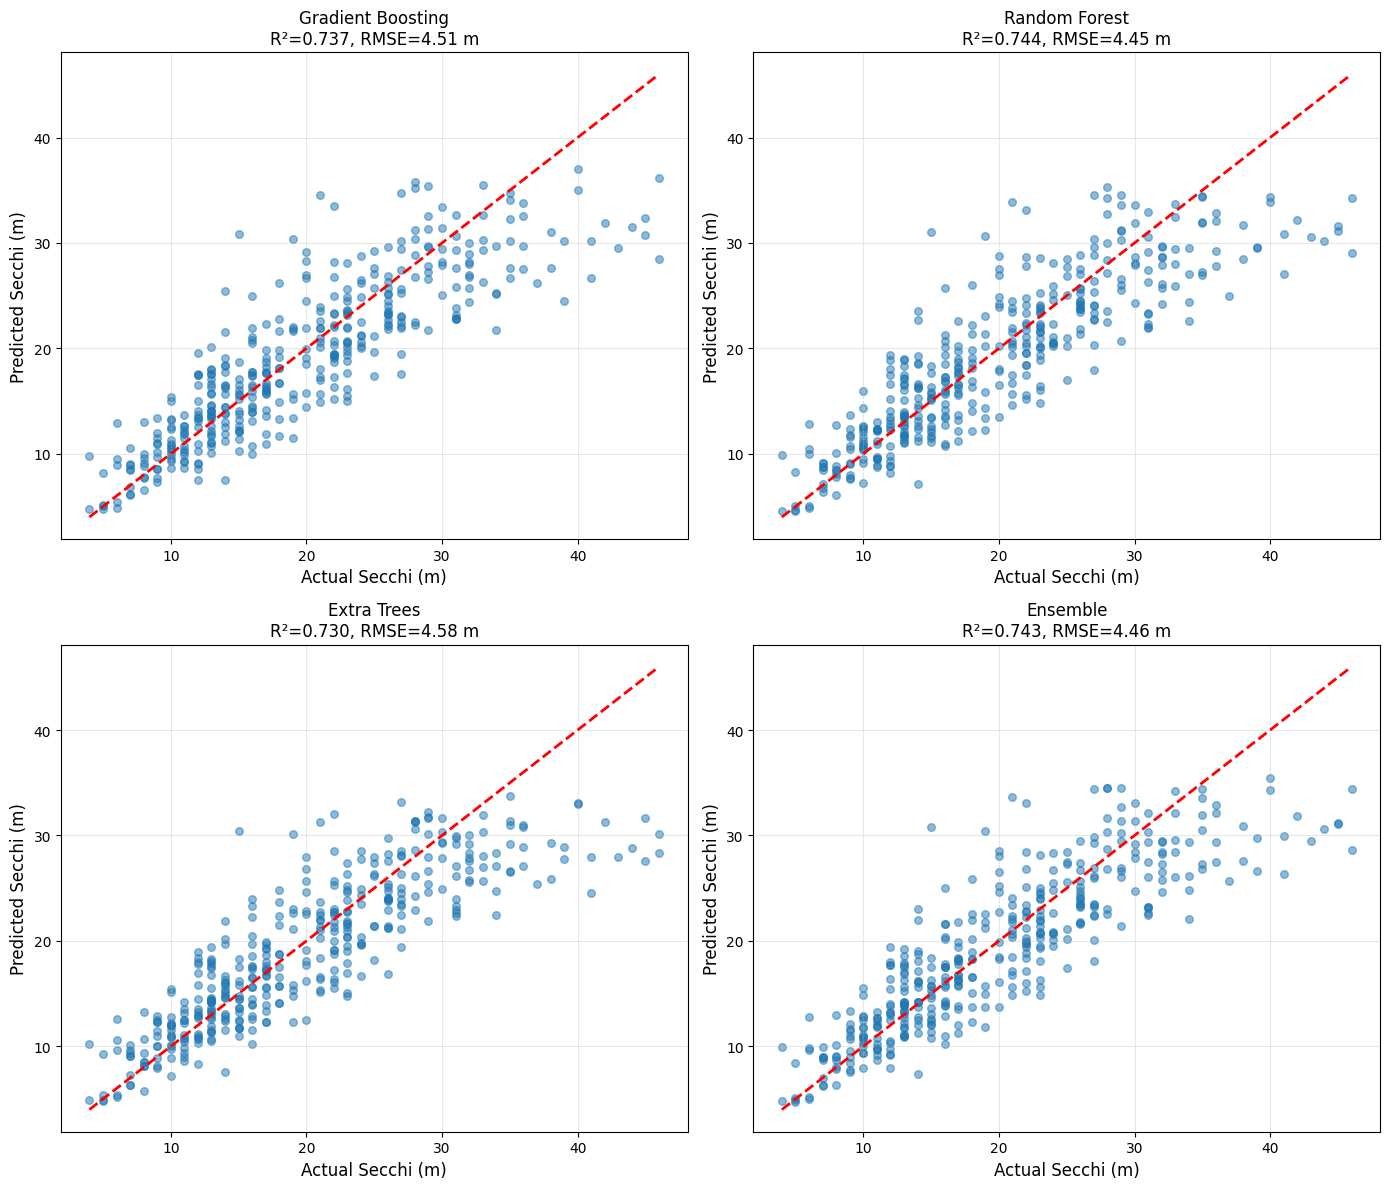

Saved: ../results/summed_enhanced47_feature_importance_specific.png


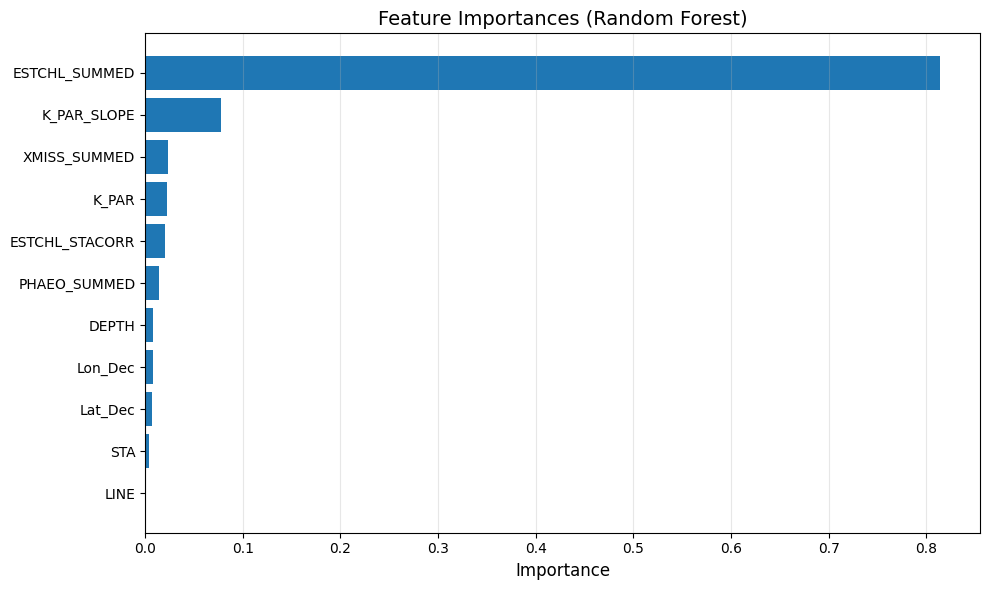

Saved: ../results/summed_enhanced47_residual_plot_specific.png


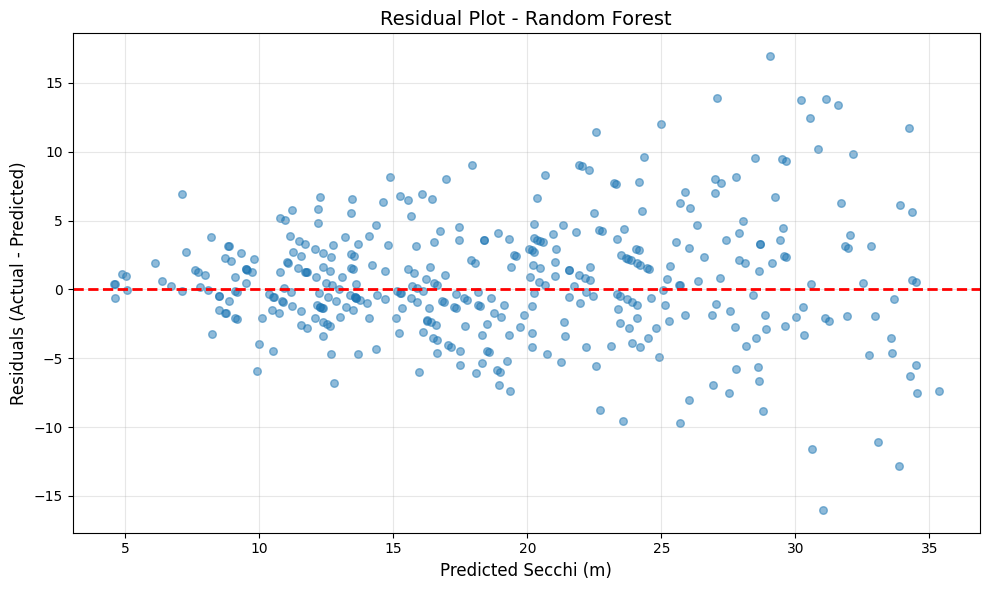

Saved: ../results/summed_enhanced47_error_distribution_specific.png


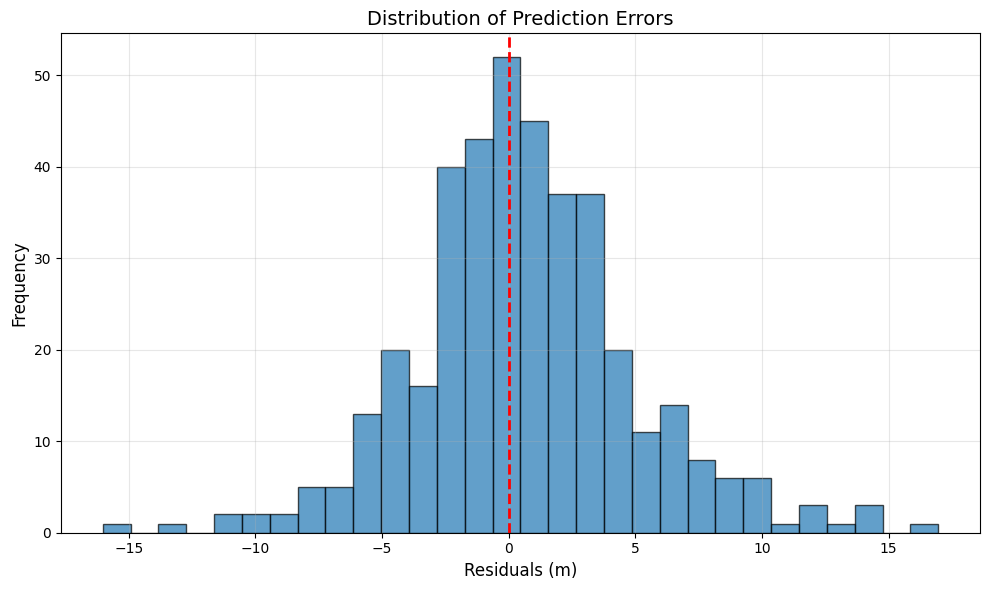


ANALYSIS COMPLETE!

Best Model: Random Forest (R² = 0.744)
Models saved to: ../Models
Results saved to: ../results


In [40]:
# Check which features exist in the dataset
missing_features = [col for col in feature_cols if col not in enhanced_df.columns]
if missing_features:
    print(f"\nWARNING: These features are missing from the dataset: {missing_features}")
    feature_cols = [col for col in feature_cols if col in df.columns]
    print(f"Using {len(feature_cols)} available features: {feature_cols}")

# Prepare X and y
X = enhanced_df[feature_cols].copy()
y = enhanced_df[target_col].copy()

# Only remove rows where TARGET is missing or invalid
mask = (y > 0) & y.notna()
X = X[mask]
y = y[mask]

print(f"\nSample size after removing invalid TARGET values: {len(X)}")

# Check NaN count per feature
nan_counts = X.isna().sum()
print(f"\nNaN counts per feature:")
for feat in feature_cols:
    if feat in nan_counts.index:
        print(f"  {feat}: {nan_counts[feat]} ({nan_counts[feat]/len(X)*100:.1f}%)")

# Log-transform target
y_log = np.log(y)

# ============================================================================
# 3. TRAIN/TEST SPLIT (BEFORE IMPUTATION)
# ============================================================================

X_train, X_test, y_train_log, y_test_log = train_test_split(
    X, y_log,
    test_size=0.2,
    random_state=42
)

print(f"\nTraining set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

# ============================================================================
# 4. IMPUTATION (Handle Missing Values)
# ============================================================================

print("\n" + "="*80)
print("IMPUTING MISSING VALUES")
print("="*80)

# Use median imputation
imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Convert back to DataFrame
X_train = pd.DataFrame(X_train_imputed, columns=X_train.columns, index=X_train.index)
X_test = pd.DataFrame(X_test_imputed, columns=X_test.columns, index=X_test.index)

print(f"Imputation complete")
print(f"Training set NaN count: {X_train.isna().sum().sum()}")
print(f"Test set NaN count: {X_test.isna().sum().sum()}")

# ============================================================================
# 5. FEATURE SCALING
# ============================================================================

print("\n" + "="*80)
print("FEATURE SCALING")
print("="*80)

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame
X_train_final = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_final = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("Scaling complete with RobustScaler")

# ============================================================================
# 6. TRAIN GRADIENT BOOSTING MODEL
# ============================================================================

print("\n" + "="*80)
print("TRAINING GRADIENT BOOSTING MODEL")
print("="*80)

hgb = HistGradientBoostingRegressor(random_state=42)

param_grid = {
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [5, 10, 15, None],
    "max_iter": [300, 500, 800],
    "min_samples_leaf": [10, 20, 50],
    "l2_regularization": [0, 0.01, 0.1]
}

print("\nStarting GridSearchCV (this may take a while)...")

grid_search = GridSearchCV(
    hgb,
    param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_final, y_train_log)

best_hgb = grid_search.best_estimator_

print("\nBest Parameters:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")

# ============================================================================
# 7. TRAIN ENSEMBLE MODELS
# ============================================================================

print("\n" + "="*80)
print("TRAINING ENSEMBLE MODELS")
print("="*80)

# Random Forest
rf = RandomForestRegressor(
    n_estimators=200, 
    max_depth=15,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)
print("Training Random Forest...")
rf.fit(X_train_final, y_train_log)

# Extra Trees
et = ExtraTreesRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)
print("Training Extra Trees...")
et.fit(X_train_final, y_train_log)

# ============================================================================
# 8. PREDICTIONS
# ============================================================================

print("\n" + "="*80)
print("MAKING PREDICTIONS")
print("="*80)

# Individual model predictions (log scale)
y_pred_hgb_log = best_hgb.predict(X_test_final)
y_pred_rf_log = rf.predict(X_test_final)
y_pred_et_log = et.predict(X_test_final)

# Back-transform to original scale
y_pred_hgb = np.exp(y_pred_hgb_log)
y_pred_rf = np.exp(y_pred_rf_log)
y_pred_et = np.exp(y_pred_et_log)
y_test = np.exp(y_test_log)

# Ensemble prediction (weighted average)
y_pred_ensemble = (0.5 * y_pred_hgb + 0.3 * y_pred_rf + 0.2 * y_pred_et)

# ============================================================================
# 9. EVALUATION
# ============================================================================

print("\n" + "="*80)
print("MODEL EVALUATION")
print("="*80)

models_results = {
    'Gradient Boosting': y_pred_hgb,
    'Random Forest': y_pred_rf,
    'Extra Trees': y_pred_et,
    'Ensemble': y_pred_ensemble
}

best_r2 = -np.inf
best_model_name = None

for model_name, y_pred in models_results.items():
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    if r2 > best_r2:
        best_r2 = r2
        best_model_name = model_name
    
    print(f"\n{model_name}:")
    print(f"  RMSE: {rmse:.3f} m")
    print(f"  MAE:  {mae:.3f} m")
    print(f"  R²:   {r2:.3f}")

print(f"\n{'='*80}")
print(f"BEST MODEL: {best_model_name} (R² = {best_r2:.3f})")
print(f"{'='*80}")

# ============================================================================
# 10. FEATURE IMPORTANCE
# ============================================================================

print("\n" + "="*80)
print("FEATURE IMPORTANCE")
print("="*80)

feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature Importances (from Random Forest):")
print(feature_importance.to_string(index=False))

# ============================================================================
# 11. SAVE MODELS
# ============================================================================

print("\n" + "="*80)
print("SAVING MODELS")
print("="*80)

models_dir = Path("../Models")
models_dir.mkdir(exist_ok=True)

# Save models
joblib.dump(best_hgb, models_dir / "summed_GradientBoost_specific_features.pkl")
joblib.dump(rf, models_dir / "summed_RandomForest_specific_features.pkl")
joblib.dump(et, models_dir / "summed_ExtraTrees_specific_features.pkl")
joblib.dump(scaler, models_dir / "summed_scaler_specific_features.pkl")
joblib.dump(imputer, models_dir / "summed_imputer_specific_features.pkl")

# Save feature list
pd.DataFrame({'features': feature_cols}).to_csv(models_dir / "summed_selected_features.csv", index=False)

# Save feature importance
feature_importance.to_csv(models_dir / "summed_enhanced47_feature_importance.csv", index=False)

print(f"\nAll models saved to {models_dir}")

# ============================================================================
# 12. VISUALIZATIONS
# ============================================================================

print("\n" + "="*80)
print("CREATING VISUALIZATIONS")
print("="*80)

results_dir = Path("../results")
results_dir.mkdir(exist_ok=True)

# Figure 1: Actual vs Predicted (all models)
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, (model_name, y_pred) in enumerate(models_results.items()):
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    axes[idx].scatter(y_test, y_pred, alpha=0.5, s=30)
    
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    
    axes[idx].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
    axes[idx].set_xlabel("Actual Secchi (m)", fontsize=12)
    axes[idx].set_ylabel("Predicted Secchi (m)", fontsize=12)
    axes[idx].set_title(f"{model_name}\nR²={r2:.3f}, RMSE={rmse:.2f} m", fontsize=12)
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(results_dir / "summed_enhanced47_model_comparison_specific_features.png", dpi=300, bbox_inches='tight')
print(f"Saved: {results_dir / 'summed_enhanced47_model_comparison_specific_features.png'}")
plt.show()

# Figure 2: Feature Importance
plt.figure(figsize=(10, 6))
plt.barh(range(len(feature_importance)), feature_importance['importance'])
plt.yticks(range(len(feature_importance)), feature_importance['feature'])
plt.xlabel('Importance', fontsize=12)
plt.title('Feature Importances (Random Forest)', fontsize=14)
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(results_dir / "summed_enhanced47_feature_importance_specific.png", dpi=300, bbox_inches='tight')
print(f"Saved: {results_dir / 'summed_enhanced47_feature_importance_specific.png'}")
plt.show()

# Figure 3: Residual Plot (Best Model)
best_pred = models_results[best_model_name]
residuals = y_test - best_pred

plt.figure(figsize=(10, 6))
plt.scatter(best_pred, residuals, alpha=0.5, s=30)
plt.axhline(0, color='red', linestyle='--', lw=2)
plt.xlabel("Predicted Secchi (m)", fontsize=12)
plt.ylabel("Residuals (Actual - Predicted)", fontsize=12)
plt.title(f"Residual Plot - {best_model_name}", fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(results_dir / "summed_enhanced47_residual_plot_specific.png", dpi=300, bbox_inches='tight')
print(f"Saved: {results_dir / 'summed_enhanced47_residual_plot_specific.png'}")
plt.show()

# Figure 4: Error Distribution
plt.figure(figsize=(10, 6))
plt.hist(residuals, bins=30, edgecolor='black', alpha=0.7)
plt.axvline(0, color='red', linestyle='--', lw=2)
plt.xlabel("Residuals (m)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.title("Distribution of Prediction Errors", fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(results_dir / "summed_enhanced47_error_distribution_specific.png", dpi=300, bbox_inches='tight')
print(f"Saved: {results_dir / 'summed_enhanced47_error_distribution_specific.png'}")
plt.show()

print("\n" + "="*80)
print("ANALYSIS COMPLETE!")
print("="*80)
print(f"\nBest Model: {best_model_name} (R² = {best_r2:.3f})")
print(f"Models saved to: {models_dir}")
print(f"Results saved to: {results_dir}")

# Threshold Comparison First using STA

Loading data...
Total observations with valid coordinates: 1971

CREATING SPATIAL VISUALIZATIONS
Saved: ../results/spatial_distribution.png


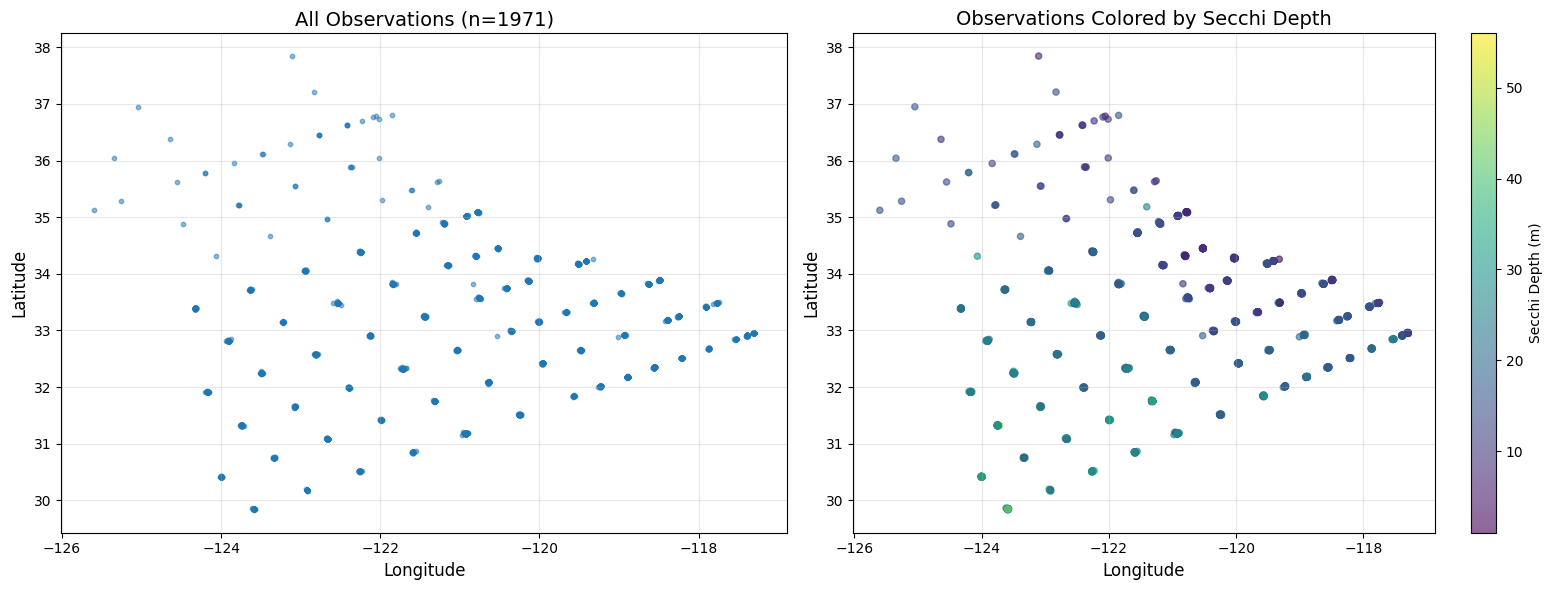


Calculating distance from coast proxy...

Using STA column:
  Near coast (STA ≤ 60): 1102
  Offshore (STA > 60): 869


/var/folders/mn/p1lvhfv92fq50k75hv7x4b0m0000gn/T/ipykernel_22250/3706705180.py:120: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 0].boxplot(data_to_plot, labels=['Near Coast', 'Offshore'])


Saved: ../results/coastal_vs_offshore_analysis.png


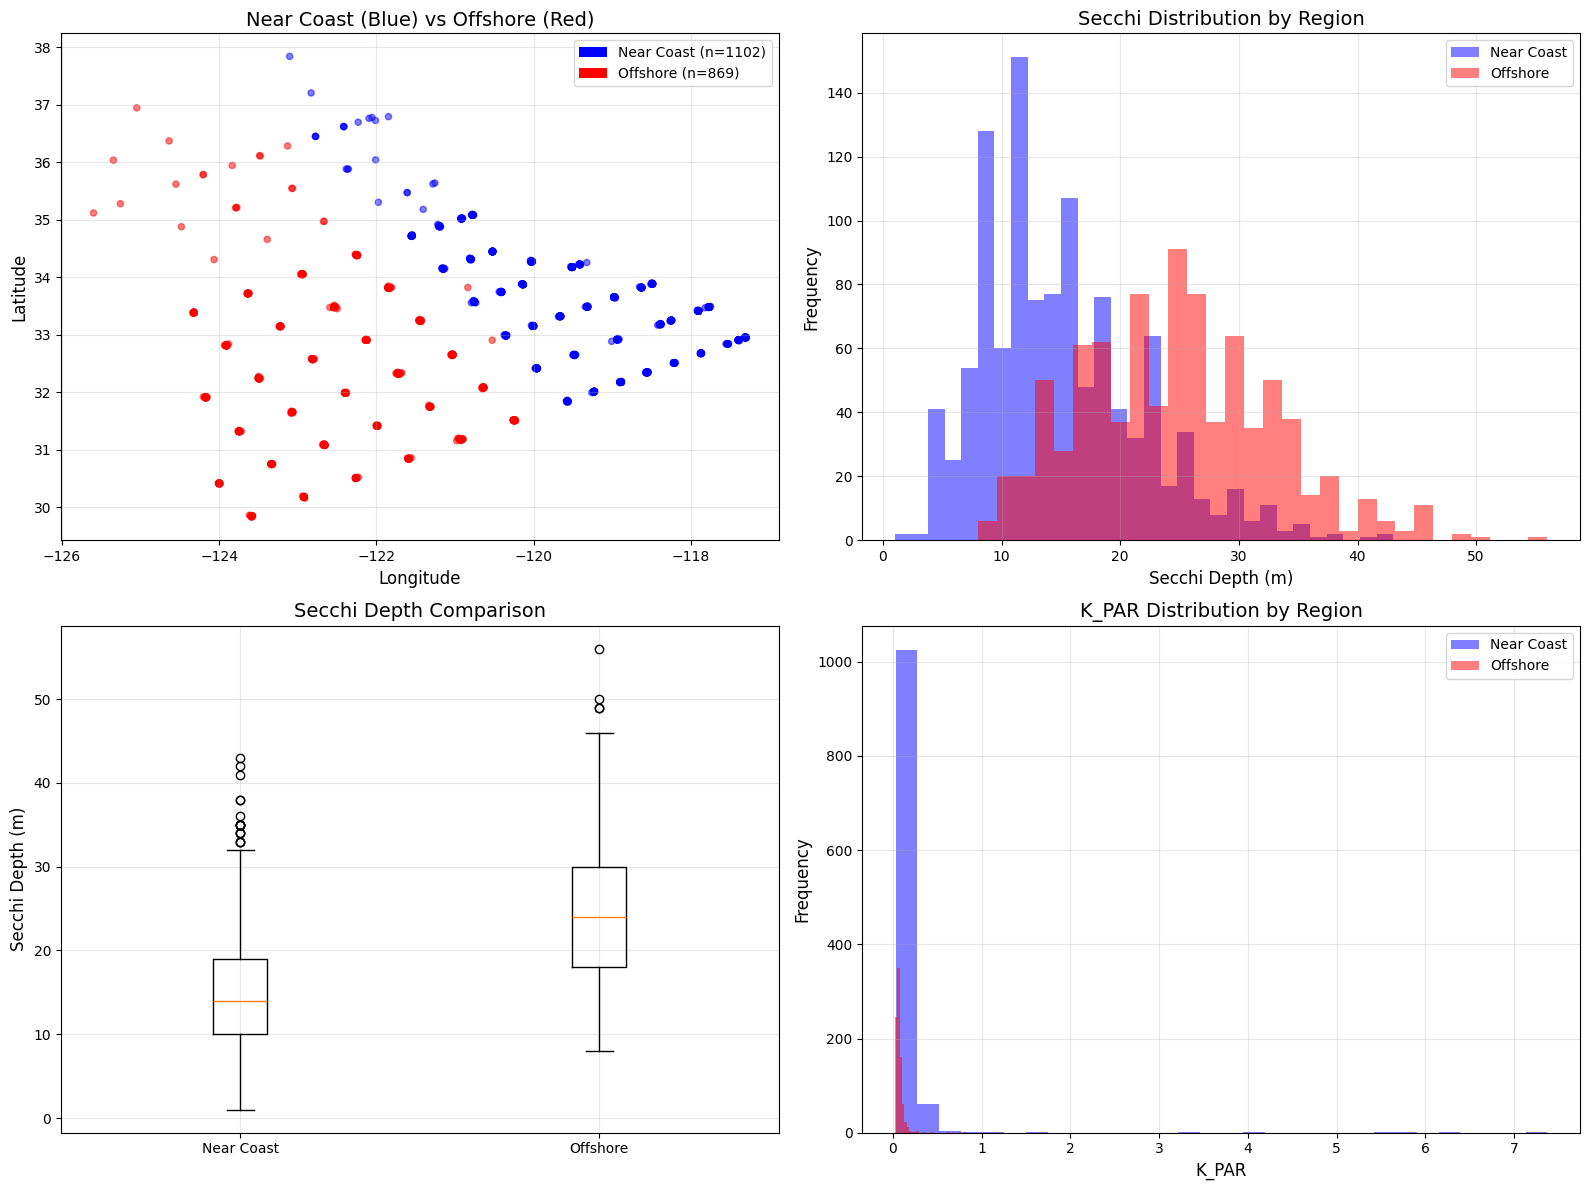


STATISTICAL COMPARISON

Secchi Depth Comparison:
  Near Coast - Mean: 14.87m, Std: 6.74m
  Offshore   - Mean: 24.51m, Std: 8.03m
  T-test: t=-28.9371, p=1.0118e-153
  ✓ Statistically significant difference (p < 0.05)

     Feature  Near_Coast_Mean  Offshore_Mean  T_Statistic       P_Value Significant
       K_PAR         0.171462       0.073962     6.446382  1.436791e-10         Yes
XMISS_SUMMED      1283.018722    1390.029666    -3.821649  1.366767e-04         Yes
CHL_A_SUMMED         5.656197       0.691717    14.938303  7.023256e-48         Yes
       DEPTH        29.870236      52.298044   -29.364922 1.649802e-157         Yes

Comparison saved to: ../results/coastal_offshore_comparison.csv

CORRELATION ANALYSIS BY REGION
Saved: ../results/correlation_by_region.png


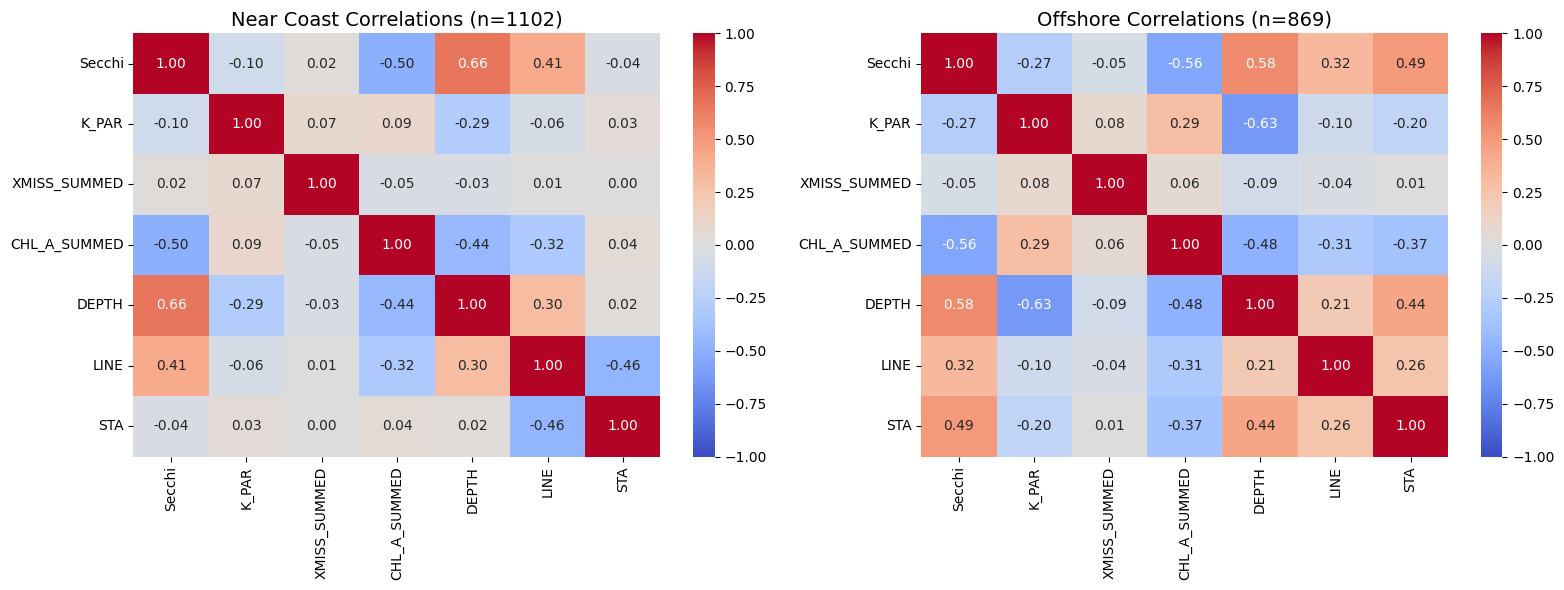


RECOMMENDATION

✓ RECOMMENDATION: Split dataset into coastal/offshore
  Reason: 4 features show significant differences
  Features: K_PAR, XMISS_SUMMED, CHL_A_SUMMED, DEPTH

  Benefits:
  - Different environmental conditions → different predictive relationships
  - Separate models may capture region-specific patterns better
  - Can identify which features matter most in each region

ANALYSIS COMPLETE!


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ============================================================================
# LOAD DATA
# ============================================================================

print("Loading data...")
# Assuming enhanced_df is your dataframe with photic zone observations
df = enhanced_df.copy()

# Remove rows with missing Lat/Lon
df = df[df['Lat_Dec'].notna() & df['Lon_Dec'].notna()].copy()

print(f"Total observations with valid coordinates: {len(df)}")

# ============================================================================
# BASIC SPATIAL VISUALIZATION
# ============================================================================

print("\n" + "="*80)
print("CREATING SPATIAL VISUALIZATIONS")
print("="*80)

results_dir = Path("../results")
results_dir.mkdir(exist_ok=True)

# Figure 1: Simple scatter plot of all observations
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: All observations
axes[0].scatter(df['Lon_Dec'], df['Lat_Dec'], alpha=0.5, s=10)
axes[0].set_xlabel('Longitude', fontsize=12)
axes[0].set_ylabel('Latitude', fontsize=12)
axes[0].set_title(f'All Observations (n={len(df)})', fontsize=14)
axes[0].grid(True, alpha=0.3)

# Plot 2: Colored by Secchi depth
scatter = axes[1].scatter(df['Lon_Dec'], df['Lat_Dec'], 
                         c=df['Secchi'], cmap='viridis', 
                         alpha=0.6, s=20)
axes[1].set_xlabel('Longitude', fontsize=12)
axes[1].set_ylabel('Latitude', fontsize=12)
axes[1].set_title('Observations Colored by Secchi Depth', fontsize=14)
axes[1].grid(True, alpha=0.3)
plt.colorbar(scatter, ax=axes[1], label='Secchi Depth (m)')

plt.tight_layout()
plt.savefig(results_dir / "spatial_distribution.png", dpi=300, bbox_inches='tight')
print(f"Saved: {results_dir / 'spatial_distribution.png'}")
plt.show()

# ============================================================================
# CALCULATE DISTANCE FROM COAST
# ============================================================================

print("\nCalculating distance from coast proxy...")

# Using STA column if available (STA <= 60 typically means near shore)
if 'STA' in df.columns:
    df['NEAR_COAST'] = (df['STA'] <= 60)
    
    near_coast_count = df['NEAR_COAST'].sum()
    offshore_count = (~df['NEAR_COAST']).sum()
    
    print(f"\nUsing STA column:")
    print(f"  Near coast (STA ≤ 60): {near_coast_count}")
    print(f"  Offshore (STA > 60): {offshore_count}")
else:
    # Calculate distance from approximate coastline
    # California coast is roughly at Lon = -120 to -117
    df['DIST_FROM_COAST'] = np.abs(df['Lon_Dec'] + 120)
    
    # Define near coast as within ~50km (roughly 0.5 degrees longitude)
    df['NEAR_COAST'] = df['DIST_FROM_COAST'] < 0.5
    
    near_coast_count = df['NEAR_COAST'].sum()
    offshore_count = (~df['NEAR_COAST']).sum()
    
    print(f"\nUsing distance calculation:")
    print(f"  Near coast: {near_coast_count}")
    print(f"  Offshore: {offshore_count}")

# ============================================================================
# VISUALIZE COASTAL VS OFFSHORE
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Spatial distribution colored by coastal/offshore
colors = ['blue' if x else 'red' for x in df['NEAR_COAST']]
axes[0, 0].scatter(df['Lon_Dec'], df['Lat_Dec'], c=colors, alpha=0.5, s=20)
axes[0, 0].set_xlabel('Longitude', fontsize=12)
axes[0, 0].set_ylabel('Latitude', fontsize=12)
axes[0, 0].set_title('Near Coast (Blue) vs Offshore (Red)', fontsize=14)
axes[0, 0].grid(True, alpha=0.3)
# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='blue', label=f'Near Coast (n={near_coast_count})'),
                   Patch(facecolor='red', label=f'Offshore (n={offshore_count})')]
axes[0, 0].legend(handles=legend_elements, loc='best')

# Plot 2: Secchi distribution by region
near_coast_secchi = df[df['NEAR_COAST']]['Secchi']
offshore_secchi = df[~df['NEAR_COAST']]['Secchi']

axes[0, 1].hist(near_coast_secchi, bins=30, alpha=0.5, label='Near Coast', color='blue')
axes[0, 1].hist(offshore_secchi, bins=30, alpha=0.5, label='Offshore', color='red')
axes[0, 1].set_xlabel('Secchi Depth (m)', fontsize=12)
axes[0, 1].set_ylabel('Frequency', fontsize=12)
axes[0, 1].set_title('Secchi Distribution by Region', fontsize=14)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Box plot comparison
data_to_plot = [near_coast_secchi.dropna(), offshore_secchi.dropna()]
axes[1, 0].boxplot(data_to_plot, labels=['Near Coast', 'Offshore'])
axes[1, 0].set_ylabel('Secchi Depth (m)', fontsize=12)
axes[1, 0].set_title('Secchi Depth Comparison', fontsize=14)
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: K_PAR comparison (if available)
if 'K_PAR' in df.columns:
    near_coast_kpar = df[df['NEAR_COAST']]['K_PAR']
    offshore_kpar = df[~df['NEAR_COAST']]['K_PAR']
    
    axes[1, 1].hist(near_coast_kpar, bins=30, alpha=0.5, label='Near Coast', color='blue')
    axes[1, 1].hist(offshore_kpar, bins=30, alpha=0.5, label='Offshore', color='red')
    axes[1, 1].set_xlabel('K_PAR', fontsize=12)
    axes[1, 1].set_ylabel('Frequency', fontsize=12)
    axes[1, 1].set_title('K_PAR Distribution by Region', fontsize=14)
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
else:
    axes[1, 1].text(0.5, 0.5, 'K_PAR not available', 
                   ha='center', va='center', fontsize=14)
    axes[1, 1].axis('off')

plt.tight_layout()
plt.savefig(results_dir / "coastal_vs_offshore_analysis.png", dpi=300, bbox_inches='tight')
print(f"Saved: {results_dir / 'coastal_vs_offshore_analysis.png'}")
plt.show()

# ============================================================================
# STATISTICAL COMPARISON
# ============================================================================

print("\n" + "="*80)
print("STATISTICAL COMPARISON")
print("="*80)

from scipy import stats as scipy_stats

# Compare Secchi depths
t_stat, p_value = scipy_stats.ttest_ind(near_coast_secchi.dropna(), 
                                        offshore_secchi.dropna())

print(f"\nSecchi Depth Comparison:")
print(f"  Near Coast - Mean: {near_coast_secchi.mean():.2f}m, Std: {near_coast_secchi.std():.2f}m")
print(f"  Offshore   - Mean: {offshore_secchi.mean():.2f}m, Std: {offshore_secchi.std():.2f}m")
print(f"  T-test: t={t_stat:.4f}, p={p_value:.4e}")
if p_value < 0.05:
    print(f"  ✓ Statistically significant difference (p < 0.05)")
else:
    print(f"  ✗ No significant difference (p >= 0.05)")

# Compare other features if available
feature_comparison = []
for feature in ['K_PAR', 'XMISS_SUMMED', 'CHL_A_SUMMED', 'PHAEO_SUMMED', 'DEPTH']:
    if feature in df.columns:
        near = df[df['NEAR_COAST']][feature].dropna()
        off = df[~df['NEAR_COAST']][feature].dropna()
        
        if len(near) > 0 and len(off) > 0:
            t_stat, p_value = scipy_stats.ttest_ind(near, off)
            
            feature_comparison.append({
                'Feature': feature,
                'Near_Coast_Mean': near.mean(),
                'Offshore_Mean': off.mean(),
                'T_Statistic': t_stat,
                'P_Value': p_value,
                'Significant': 'Yes' if p_value < 0.05 else 'No'
            })

comparison_df = pd.DataFrame(feature_comparison)
print(f"\n{comparison_df.to_string(index=False)}")

# Save comparison
comparison_df.to_csv(results_dir / "coastal_offshore_comparison.csv", index=False)
print(f"\nComparison saved to: {results_dir / 'coastal_offshore_comparison.csv'}")

# ============================================================================
# CORRELATION HEATMAPS BY REGION
# ============================================================================

print("\n" + "="*80)
print("CORRELATION ANALYSIS BY REGION")
print("="*80)

# Select numeric columns for correlation
numeric_cols = ['Secchi', 'K_PAR', 'XMISS_SUMMED', 'CHL_A_SUMMED', 
                'PHAEO_SUMMED', 'DEPTH', 'LINE', 'STA']
available_cols = [col for col in numeric_cols if col in df.columns]

if len(available_cols) > 2:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Near coast correlation
    near_coast_corr = df[df['NEAR_COAST']][available_cols].corr()
    sns.heatmap(near_coast_corr, annot=True, fmt='.2f', cmap='coolwarm', 
                center=0, ax=axes[0], vmin=-1, vmax=1)
    axes[0].set_title(f'Near Coast Correlations (n={near_coast_count})', fontsize=14)
    
    # Offshore correlation
    offshore_corr = df[~df['NEAR_COAST']][available_cols].corr()
    sns.heatmap(offshore_corr, annot=True, fmt='.2f', cmap='coolwarm', 
                center=0, ax=axes[1], vmin=-1, vmax=1)
    axes[1].set_title(f'Offshore Correlations (n={offshore_count})', fontsize=14)
    
    plt.tight_layout()
    plt.savefig(results_dir / "correlation_by_region.png", dpi=300, bbox_inches='tight')
    print(f"Saved: {results_dir / 'correlation_by_region.png'}")
    plt.show()

# ============================================================================
# RECOMMENDATION
# ============================================================================

print("\n" + "="*80)
print("RECOMMENDATION")
print("="*80)

# Check if there's a significant difference
significant_features = comparison_df[comparison_df['Significant'] == 'Yes']['Feature'].tolist() if len(comparison_df) > 0 else []

if len(significant_features) >= 2:
    print(f"\n✓ RECOMMENDATION: Split dataset into coastal/offshore")
    print(f"  Reason: {len(significant_features)} features show significant differences")
    print(f"  Features: {', '.join(significant_features)}")
    print(f"\n  Benefits:")
    print(f"  - Different environmental conditions → different predictive relationships")
    print(f"  - Separate models may capture region-specific patterns better")
    print(f"  - Can identify which features matter most in each region")
else:
    print(f"\n✗ RECOMMENDATION: Keep dataset combined")
    print(f"  Reason: Only {len(significant_features)} features show significant differences")
    print(f"  The regions may be too similar to benefit from separate models")

print("\n" + "="*80)
print("ANALYSIS COMPLETE!")
print("="*80)

# Random Forests with split

PREPARING DATA WITH COASTAL/OFFSHORE SPLIT

Number of features: 9
Features: ['LINE', 'DEPTH', 'ESTCHL_STACORR', 'XMISS_SUMMED', 'CHL_A_SUMMED', 'Lat_Dec', 'Lon_Dec', 'K_PAR', 'K_PAR_SLOPE']

Dataset split:
  Near Coast (STA ≤ 60): 1102 observations
  Offshore (STA > 60):   869 observations

NEAR COAST MODELS

TRAINING: near_coast_random_forest

Sample size after removing invalid targets: 1102

Train/Test split:
  Training: 881 samples
  Test:     221 samples
Imputation complete (strategy: median)

Performing 5-Fold Cross-Validation...
CV RMSE: 3.6943 ± 0.1658
CV R²:   0.6941 ± 0.0525

Training Performance:
  RMSE: 1.7322
  R²:   0.9346

Test Performance:
  RMSE: 3.5329
  R²:   0.7115

Top 10 Features:
       feature  importance
  CHL_A_SUMMED    0.669471
   K_PAR_SLOPE    0.064298
         K_PAR    0.063974
  XMISS_SUMMED    0.059262
ESTCHL_STACORR    0.045035
       Lon_Dec    0.031088
         DEPTH    0.031058
       Lat_Dec    0.029820
          LINE    0.005995

TRAINING: near_coa

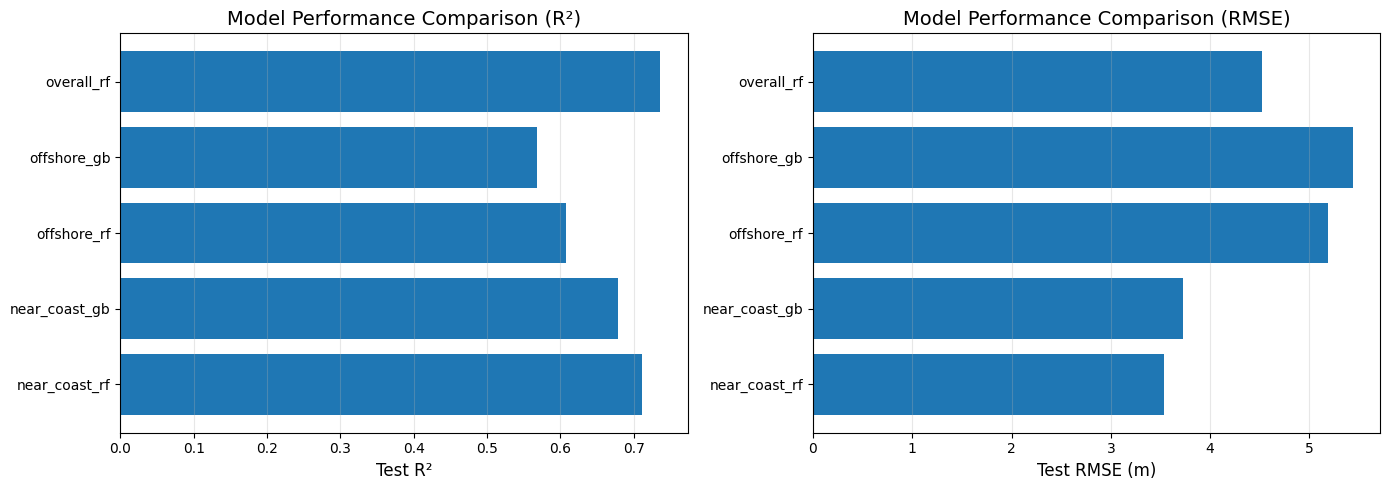

Saved: ../results/regional_predictions.png


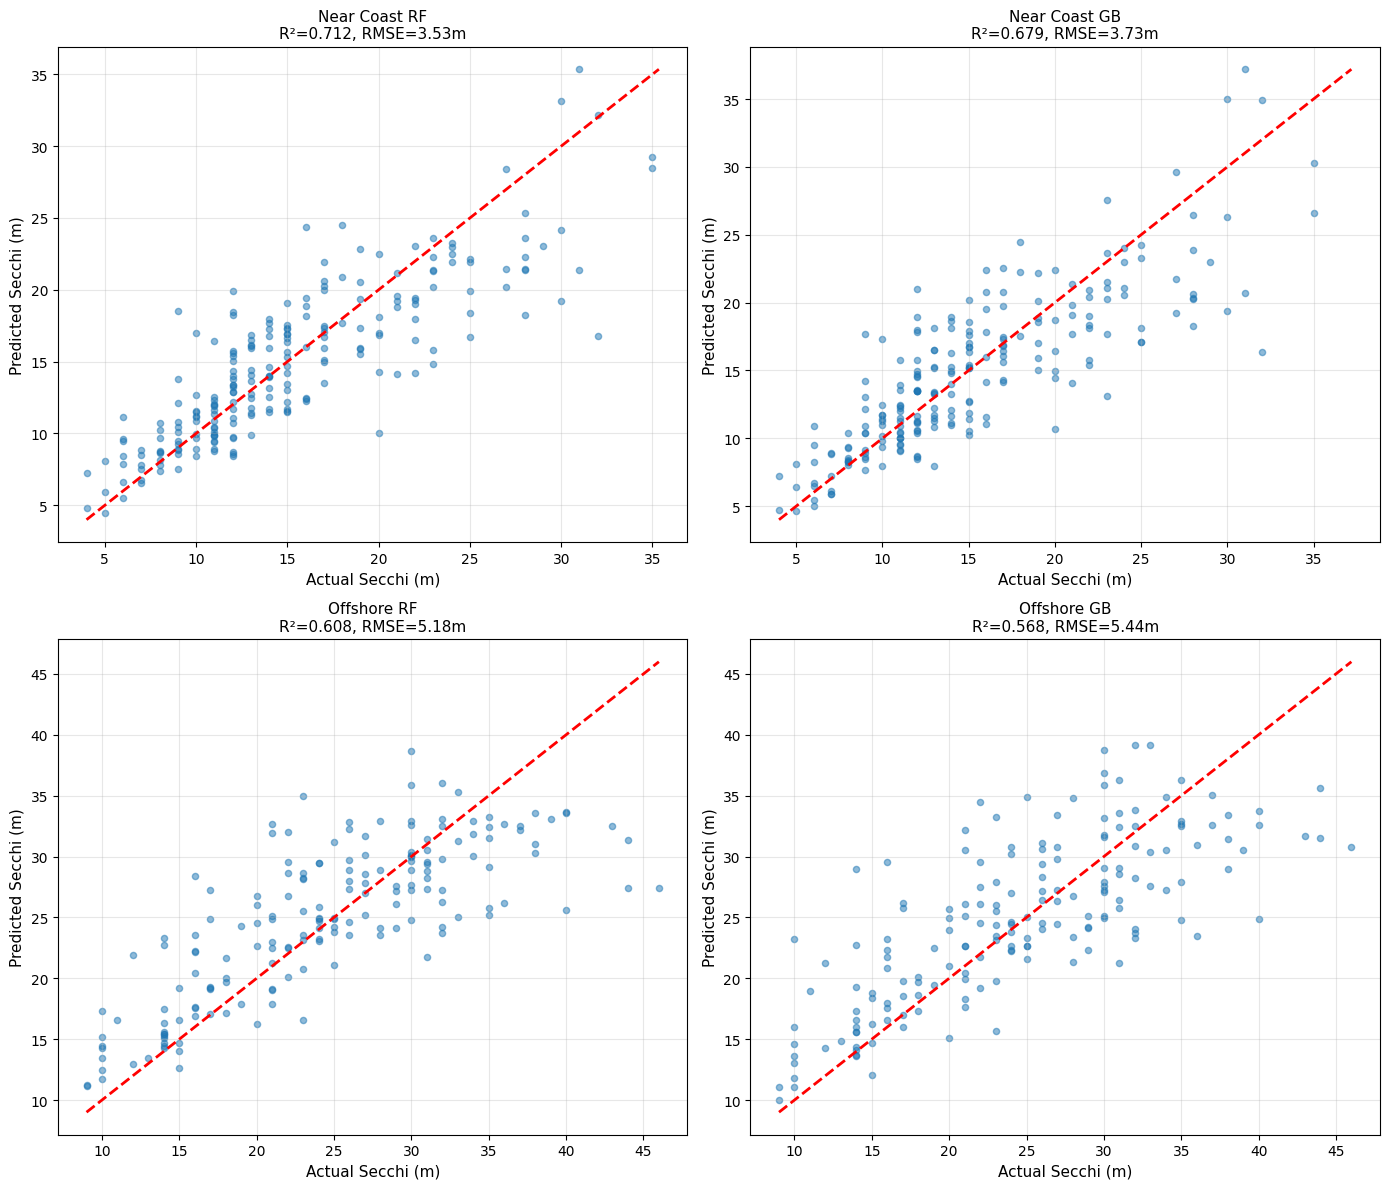

Saved: ../results/feature_importance_comparison.png


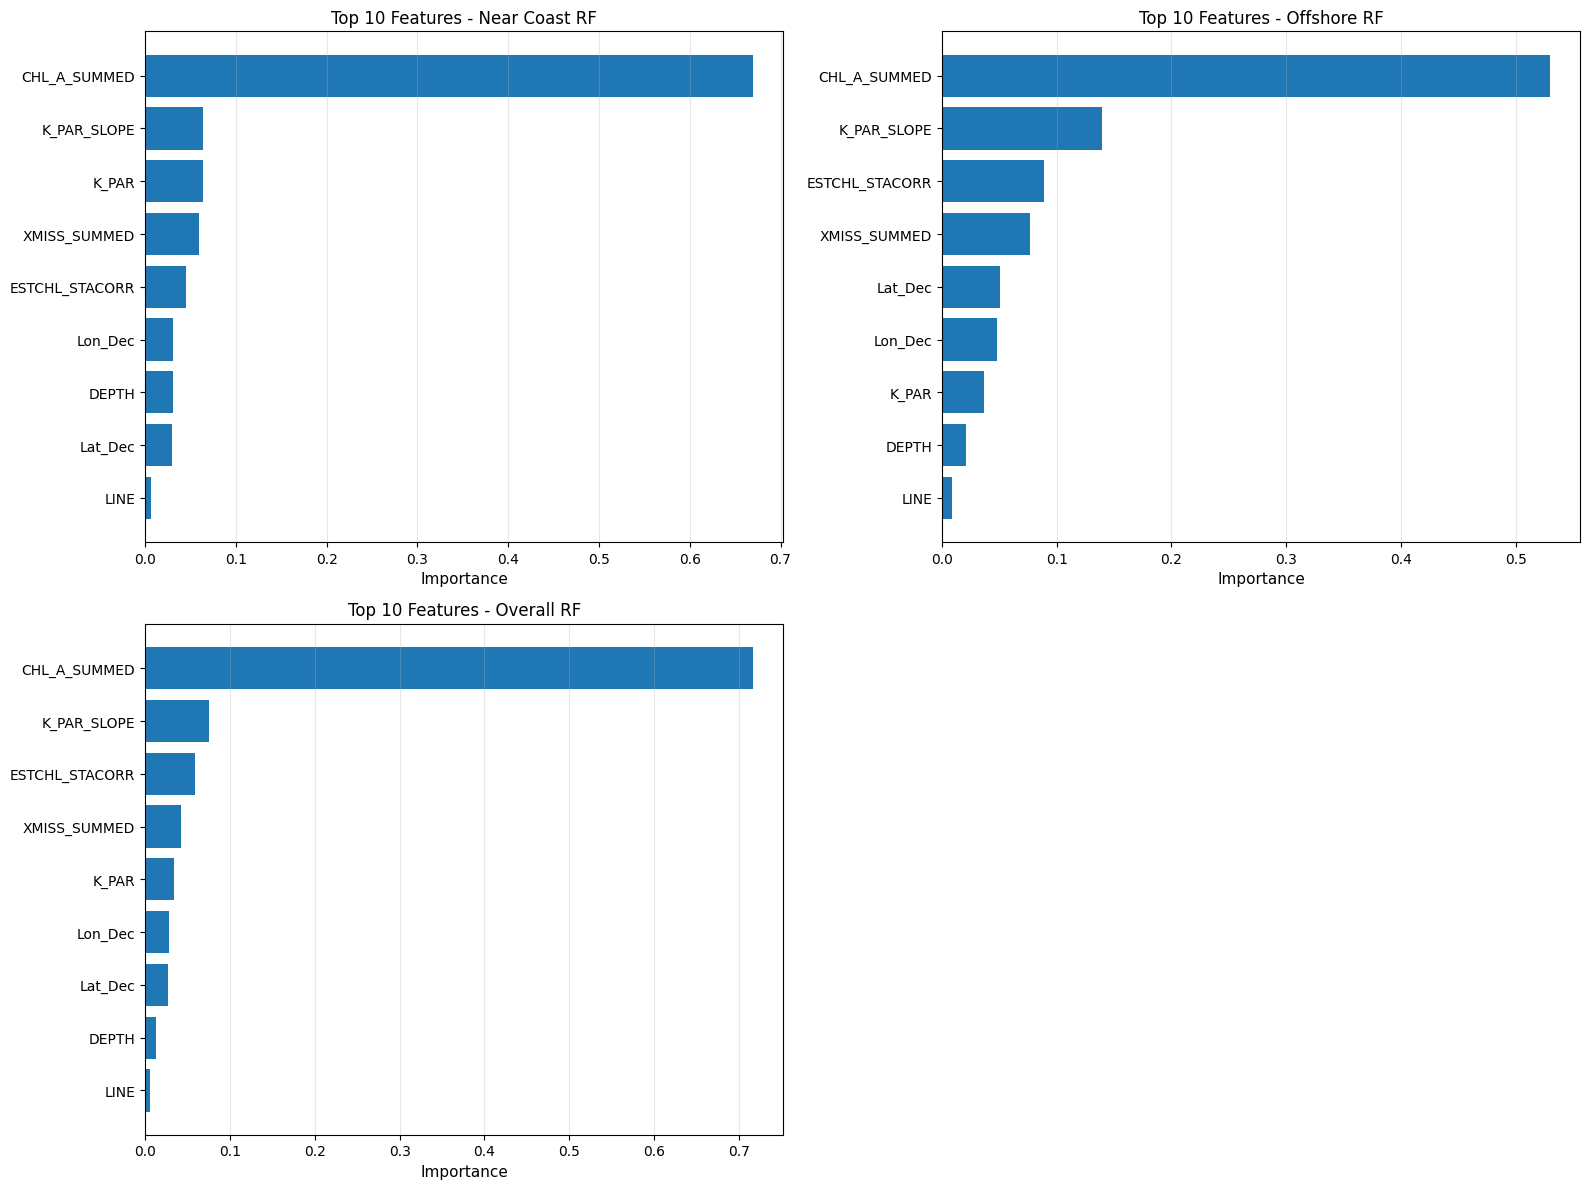


RECOMMENDATION

Performance Comparison:
  Near Coast R²:  0.7115
  Offshore R²:    0.6079
  Average Regional: 0.6597
  Overall R²:     0.7364

✗ RECOMMENDATION: Use single overall model
  Regional split doesn't provide meaningful improvement
  Difference: -7.7%

ANALYSIS COMPLETE!

All models saved to: ../Models
All results saved to: ../results


In [14]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.impute import SimpleImputer
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================================
# SETUP
# ============================================================================

exclude_cols = ['ORD_OCC', 'CAST_ID', 'DATE_TIME_UTC', 'DATE_TIME_PST', 'LAT_DEC',
       'LON_DEC', 'STA_ID', 'PRESSURE',
       'ESTCHL_CRUISECORR', 'BAT', 'XMISS', 'SPAR', 'PAR',
       'CHL_A', 'PHAEO', 'CAST_COUNT', 'PHOTIC_ZONE', 
       'Cruise_ID', 'Cruz_Sta', 'Cast_ID', 'Sta_ID',
       'Distance', 'Date', 'Time', 'Ac_Line', 'Bottom_D',
       'IntChl', 'IntC14', 'TimeZone', 'Visibility', 'STA'  # Exclude STA since we're using it to split
]

target_col = "Secchi"

models_dir = Path("../Models")
models_dir.mkdir(exist_ok=True)

results_dir = Path("../results")
results_dir.mkdir(exist_ok=True)

# ============================================================================
# PREPARE DATA
# ============================================================================

print("="*80)
print("PREPARING DATA WITH COASTAL/OFFSHORE SPLIT")
print("="*80)

# Feature columns
feature_cols = [col for col in enhanced_df.columns if col not in exclude_cols + [target_col]]

print(f"\nNumber of features: {len(feature_cols)}")
print(f"Features: {feature_cols}")

# Split by STA
near_coast_df = enhanced_df[enhanced_df['STA'] <= 60].copy()
offshore_df = enhanced_df[enhanced_df['STA'] > 60].copy()

print(f"\nDataset split:")
print(f"  Near Coast (STA ≤ 60): {len(near_coast_df)} observations")
print(f"  Offshore (STA > 60):   {len(offshore_df)} observations")

# ============================================================================
# FUNCTION TO TRAIN AND EVALUATE MODEL
# ============================================================================

def train_and_evaluate_model(df, feature_cols, target_col, model_name, model_type='rf'):
    """
    Train and evaluate a model with imputation, CV, and detailed metrics
    """
    print(f"\n{'='*80}")
    print(f"TRAINING: {model_name}")
    print(f"{'='*80}")
    
    X = df[feature_cols].copy()
    y = df[target_col].copy()
    
    # Remove rows with missing target
    mask = y.notna() & (y > 0)
    X = X[mask]
    y = y[mask]
    
    print(f"\nSample size after removing invalid targets: {len(X)}")
    
    # Check for missing values
    missing_counts = X.isna().sum()
    if missing_counts.sum() > 0:
        print(f"\nFeatures with missing values:")
        for feat in missing_counts[missing_counts > 0].index:
            print(f"  {feat}: {missing_counts[feat]} ({missing_counts[feat]/len(X)*100:.1f}%)")
    
    # Split train/test
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    
    print(f"\nTrain/Test split:")
    print(f"  Training: {len(X_train)} samples")
    print(f"  Test:     {len(X_test)} samples")
    
    # Impute missing values
    imputer = SimpleImputer(strategy='median')
    X_train_imp = imputer.fit_transform(X_train)
    X_test_imp = imputer.transform(X_test)
    
    X_train_imp = pd.DataFrame(X_train_imp, columns=X_train.columns, index=X_train.index)
    X_test_imp = pd.DataFrame(X_test_imp, columns=X_test.columns, index=X_test.index)
    
    print(f"Imputation complete (strategy: median)")
    
    # Initialize model
    if model_type == 'rf':
        model = RandomForestRegressor(
            n_estimators=200,
            max_depth=15,
            min_samples_split=5,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1
        )
    else:  # gradient boosting
        model = GradientBoostingRegressor(
            n_estimators=200,
            max_depth=5,
            learning_rate=0.1,
            min_samples_split=5,
            min_samples_leaf=2,
            random_state=42
        )
    
    # 5-fold cross-validation
    print(f"\nPerforming 5-Fold Cross-Validation...")
    kfold = KFold(n_splits=5, shuffle=True, random_state=42)
    
    cv_scores = cross_val_score(model, X_train_imp, y_train, cv=kfold, 
                                scoring='neg_mean_squared_error')
    cv_rmse = np.sqrt(-cv_scores)
    
    cv_r2 = cross_val_score(model, X_train_imp, y_train, cv=kfold, scoring='r2')
    
    print(f"CV RMSE: {cv_rmse.mean():.4f} ± {cv_rmse.std():.4f}")
    print(f"CV R²:   {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")
    
    # Train final model
    model.fit(X_train_imp, y_train)
    
    # Evaluate on train and test
    y_train_pred = model.predict(X_train_imp)
    y_test_pred = model.predict(X_test_imp)
    
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    train_r2 = r2_score(y_train, y_train_pred)
    
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    test_r2 = r2_score(y_test, y_test_pred)
    
    print(f"\nTraining Performance:")
    print(f"  RMSE: {train_rmse:.4f}")
    print(f"  R²:   {train_r2:.4f}")
    
    print(f"\nTest Performance:")
    print(f"  RMSE: {test_rmse:.4f}")
    print(f"  R²:   {test_r2:.4f}")
    
    # Feature importance
    feature_importance = pd.DataFrame({
        'feature': feature_cols,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print(f"\nTop 10 Features:")
    print(feature_importance.head(10).to_string(index=False))
    
    # Save
    model_path = models_dir / f"{model_name}.joblib"
    joblib.dump(model, model_path)
    joblib.dump(imputer, models_dir / f"{model_name}_imputer.joblib")
    feature_importance.to_csv(models_dir / f"{model_name}_importance.csv", index=False)
    
    return {
        'model': model,
        'imputer': imputer,
        'cv_rmse': cv_rmse,
        'cv_r2': cv_r2,
        'train_rmse': train_rmse,
        'train_r2': train_r2,
        'test_rmse': test_rmse,
        'test_r2': test_r2,
        'y_test': y_test,
        'y_test_pred': y_test_pred,
        'feature_importance': feature_importance,
        'X_test': X_test_imp
    }

# ============================================================================
# TRAIN MODELS
# ============================================================================

results = {}

# Near Coast Models
if len(near_coast_df) > 50:
    print("\n" + "="*80)
    print("NEAR COAST MODELS")
    print("="*80)
    
    results['near_coast_rf'] = train_and_evaluate_model(
        near_coast_df, feature_cols, target_col, 
        "near_coast_random_forest", model_type='rf'
    )
    
    results['near_coast_gb'] = train_and_evaluate_model(
        near_coast_df, feature_cols, target_col,
        "near_coast_gradient_boosting", model_type='gb'
    )

# Offshore Models
if len(offshore_df) > 50:
    print("\n" + "="*80)
    print("OFFSHORE MODELS")
    print("="*80)
    
    results['offshore_rf'] = train_and_evaluate_model(
        offshore_df, feature_cols, target_col,
        "offshore_random_forest", model_type='rf'
    )
    
    results['offshore_gb'] = train_and_evaluate_model(
        offshore_df, feature_cols, target_col,
        "offshore_gradient_boosting", model_type='gb'
    )

# Overall Model (for comparison)
print("\n" + "="*80)
print("OVERALL MODEL (For Comparison)")
print("="*80)

results['overall_rf'] = train_and_evaluate_model(
    enhanced_df, feature_cols, target_col,
    "overall_random_forest", model_type='rf'
)

# ============================================================================
# COMPARISON SUMMARY
# ============================================================================

print("\n" + "="*80)
print("MODEL COMPARISON SUMMARY")
print("="*80)

summary_data = []
for name, res in results.items():
    summary_data.append({
        'Model': name,
        'CV_R2': res['cv_r2'].mean(),
        'CV_RMSE': res['cv_rmse'].mean(),
        'Test_R2': res['test_r2'],
        'Test_RMSE': res['test_rmse']
    })

summary_df = pd.DataFrame(summary_data)
print(f"\n{summary_df.to_string(index=False)}")

# Save summary
summary_df.to_csv(results_dir / "model_comparison_summary.csv", index=False)

# ============================================================================
# VISUALIZATIONS
# ============================================================================

print("\n" + "="*80)
print("CREATING VISUALIZATIONS")
print("="*80)

# Plot 1: Model Performance Comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R² comparison
models = summary_df['Model']
test_r2 = summary_df['Test_R2']

axes[0].barh(range(len(models)), test_r2)
axes[0].set_yticks(range(len(models)))
axes[0].set_yticklabels(models)
axes[0].set_xlabel('Test R²', fontsize=12)
axes[0].set_title('Model Performance Comparison (R²)', fontsize=14)
axes[0].grid(True, alpha=0.3, axis='x')

# RMSE comparison
test_rmse = summary_df['Test_RMSE']

axes[1].barh(range(len(models)), test_rmse)
axes[1].set_yticks(range(len(models)))
axes[1].set_yticklabels(models)
axes[1].set_xlabel('Test RMSE (m)', fontsize=12)
axes[1].set_title('Model Performance Comparison (RMSE)', fontsize=14)
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(results_dir / "model_performance_comparison.png", dpi=300, bbox_inches='tight')
print(f"Saved: {results_dir / 'model_performance_comparison.png'}")
plt.show()

# Plot 2: Actual vs Predicted for each region
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

plot_configs = [
    ('near_coast_rf', 'Near Coast RF', 0),
    ('near_coast_gb', 'Near Coast GB', 1),
    ('offshore_rf', 'Offshore RF', 2),
    ('offshore_gb', 'Offshore GB', 3)
]

for model_key, title, idx in plot_configs:
    if model_key in results:
        res = results[model_key]
        
        axes[idx].scatter(res['y_test'], res['y_test_pred'], alpha=0.5, s=20)
        
        min_val = min(res['y_test'].min(), res['y_test_pred'].min())
        max_val = max(res['y_test'].max(), res['y_test_pred'].max())
        
        axes[idx].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
        axes[idx].set_xlabel('Actual Secchi (m)', fontsize=11)
        axes[idx].set_ylabel('Predicted Secchi (m)', fontsize=11)
        axes[idx].set_title(f'{title}\nR²={res["test_r2"]:.3f}, RMSE={res["test_rmse"]:.2f}m', 
                           fontsize=11)
        axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(results_dir / "regional_predictions.png", dpi=300, bbox_inches='tight')
print(f"Saved: {results_dir / 'regional_predictions.png'}")
plt.show()

# Plot 3: Feature Importance Comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

importance_configs = [
    ('near_coast_rf', 'Near Coast RF', 0),
    ('offshore_rf', 'Offshore RF', 1),
    ('overall_rf', 'Overall RF', 2)
]

for model_key, title, idx in importance_configs:
    if model_key in results:
        imp = results[model_key]['feature_importance'].head(10)
        
        axes[idx].barh(range(len(imp)), imp['importance'])
        axes[idx].set_yticks(range(len(imp)))
        axes[idx].set_yticklabels(imp['feature'])
        axes[idx].set_xlabel('Importance', fontsize=11)
        axes[idx].set_title(f'Top 10 Features - {title}', fontsize=12)
        axes[idx].invert_yaxis()
        axes[idx].grid(True, alpha=0.3, axis='x')

# Hide unused subplot
axes[3].axis('off')

plt.tight_layout()
plt.savefig(results_dir / "feature_importance_comparison.png", dpi=300, bbox_inches='tight')
print(f"Saved: {results_dir / 'feature_importance_comparison.png'}")
plt.show()

# ============================================================================
# FINAL RECOMMENDATION
# ============================================================================

print("\n" + "="*80)
print("RECOMMENDATION")
print("="*80)

# Compare regional models vs overall
if 'near_coast_rf' in results and 'offshore_rf' in results and 'overall_rf' in results:
    near_r2 = results['near_coast_rf']['test_r2']
    off_r2 = results['offshore_rf']['test_r2']
    overall_r2 = results['overall_rf']['test_r2']
    
    avg_regional_r2 = (near_r2 + off_r2) / 2
    
    print(f"\nPerformance Comparison:")
    print(f"  Near Coast R²:  {near_r2:.4f}")
    print(f"  Offshore R²:    {off_r2:.4f}")
    print(f"  Average Regional: {avg_regional_r2:.4f}")
    print(f"  Overall R²:     {overall_r2:.4f}")
    
    if avg_regional_r2 > overall_r2 + 0.02:  # 2% improvement
        print(f"\n✓ RECOMMENDATION: Use separate regional models")
        print(f"  Regional models perform {(avg_regional_r2 - overall_r2)*100:.1f}% better")
    else:
        print(f"\n✗ RECOMMENDATION: Use single overall model")
        print(f"  Regional split doesn't provide meaningful improvement")
        print(f"  Difference: {(avg_regional_r2 - overall_r2)*100:.1f}%")

print("\n" + "="*80)
print("ANALYSIS COMPLETE!")
print("="*80)
print(f"\nAll models saved to: {models_dir}")
print(f"All results saved to: {results_dir}")

# Finding Threshold w/o STA

Loading data...
Total observations with valid coordinates: 1971

EXPLORATORY SPATIAL ANALYSIS
Saved: ../results/spatial_exploration.png


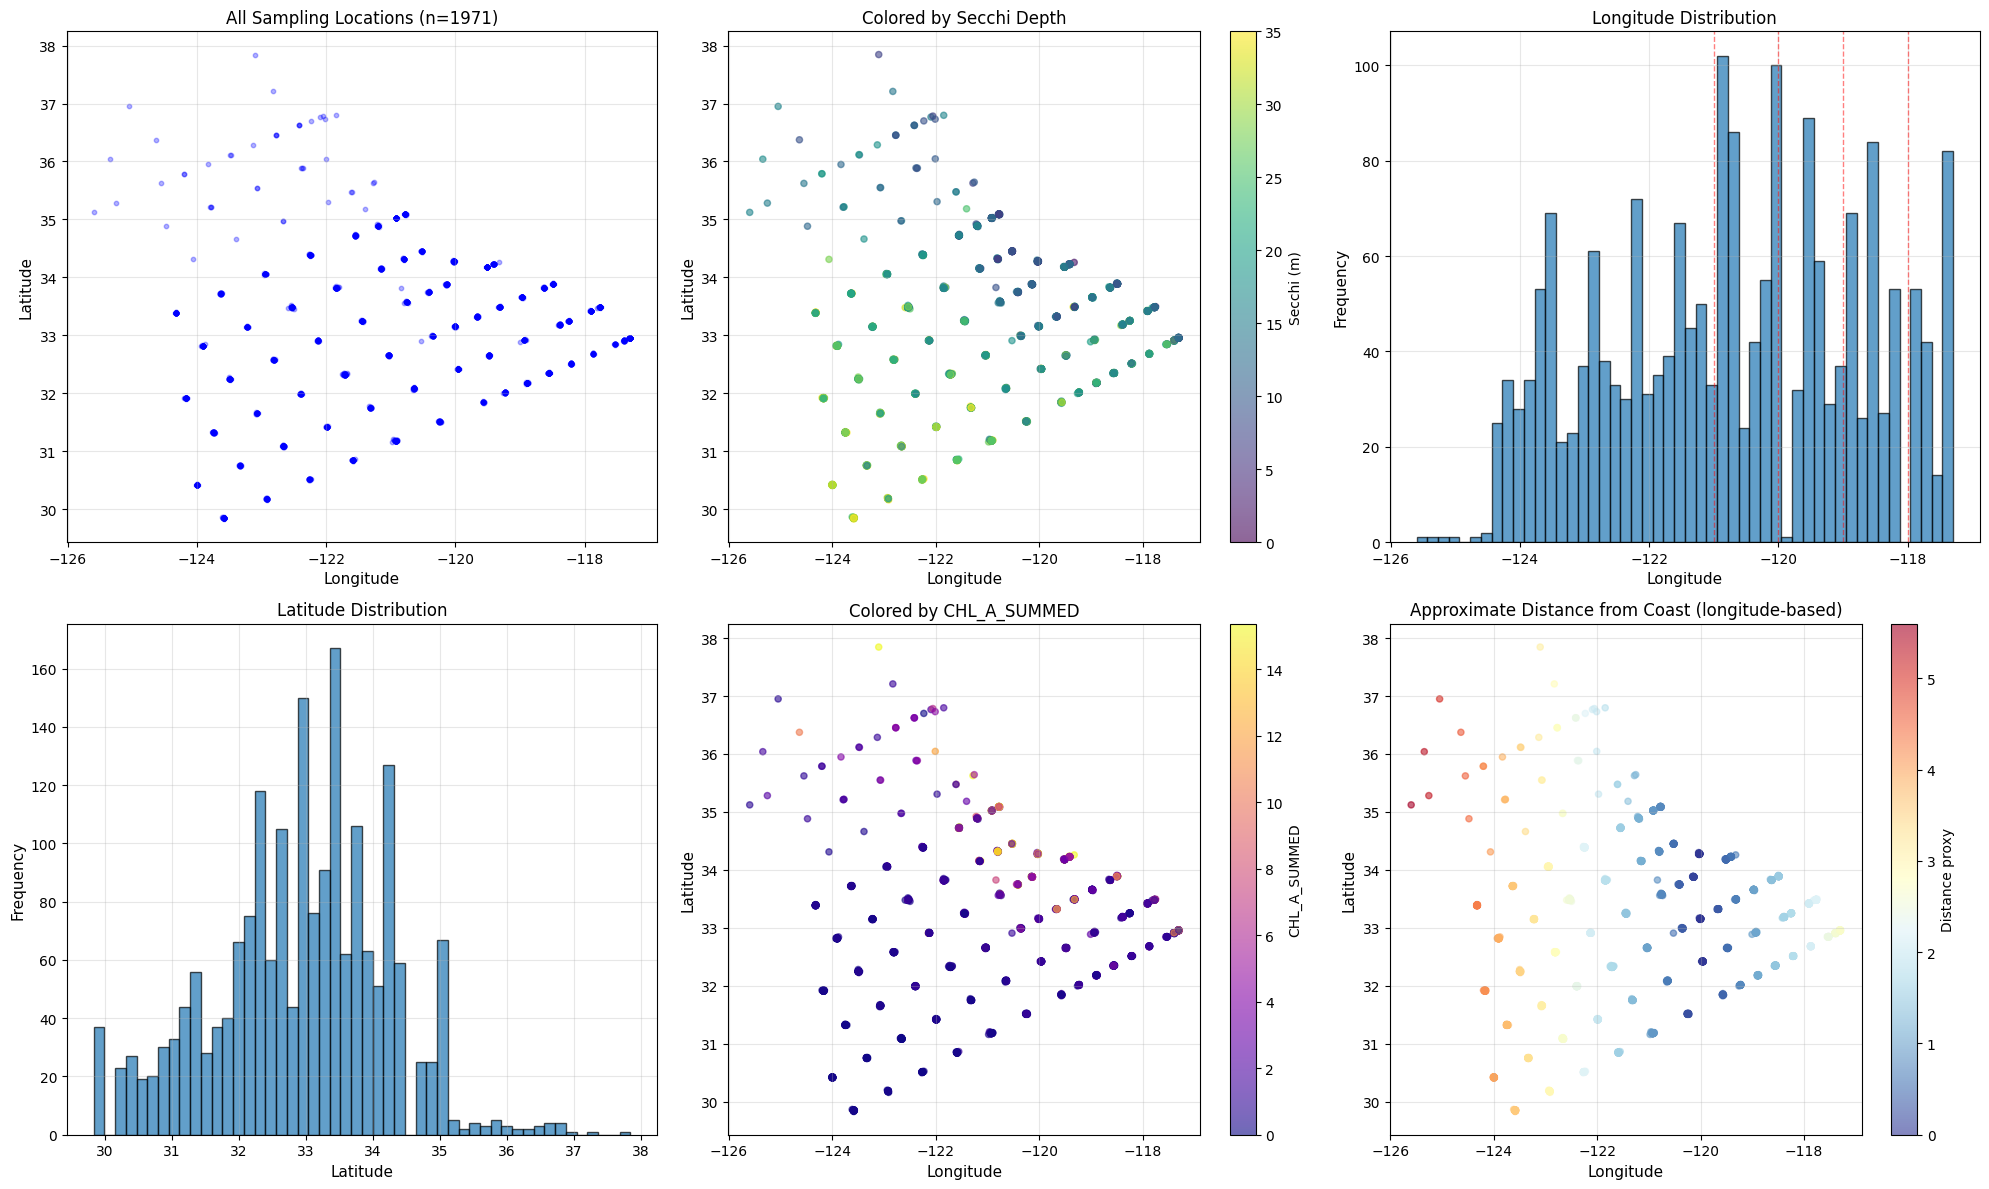


SECCHI PATTERNS BY LOCATION

Secchi statistics by Longitude bins:
                LON_BIN     Secchi                     K_PAR
                              mean       std count      mean
0  (-125.607, -124.768]  16.000000  0.816497     4  0.078235
1  (-124.768, -123.938]  29.077778  7.144146    90  0.056083
2  (-123.938, -123.108]  26.855000  7.679770   200  0.067611
3  (-123.108, -122.278]  23.698492  8.604060   199  0.077823
4  (-122.278, -121.447]  21.053279  8.230303   244  0.117796
5  (-121.447, -120.617]  16.677215  7.979155   316  0.144271
6  (-120.617, -119.787]  14.094595  7.283842   222  0.159246
7  (-119.787, -118.957]  15.825203  7.067455   246  0.177072
8  (-118.957, -118.127]  17.799228  6.900612   259  0.117692
9  (-118.127, -117.297]  15.089005  6.349259   191  0.183916
Saved: ../results/secchi_by_location.png


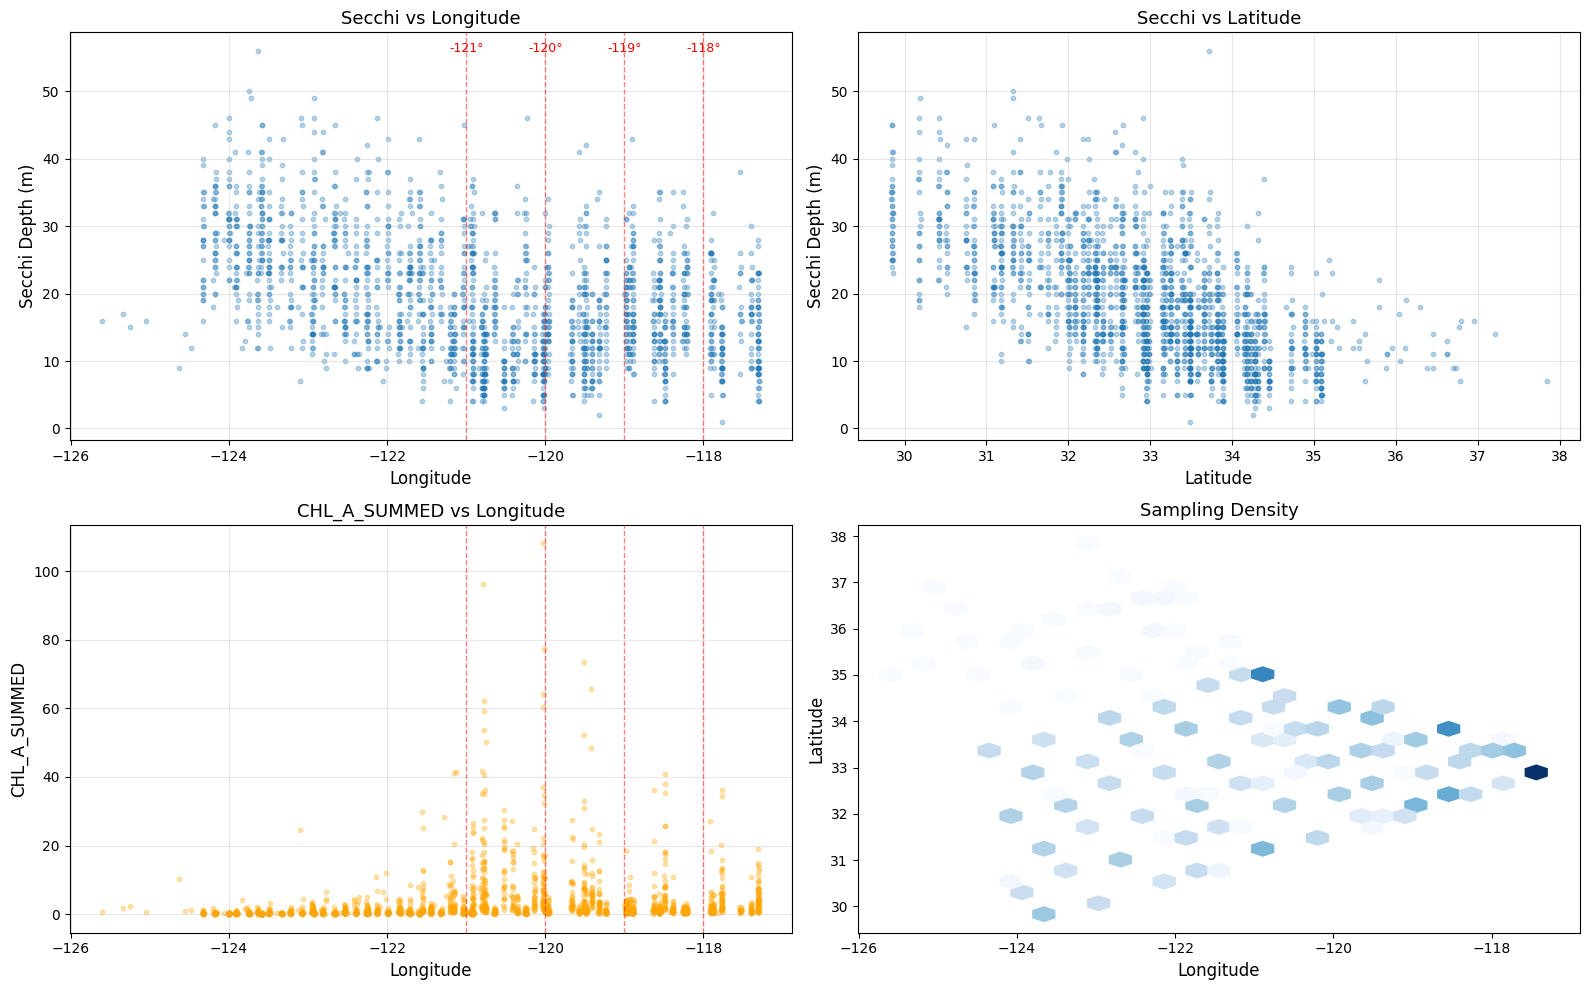


DEFINE YOUR COASTAL/OFFSHORE BOUNDARY

Based on the visualizations above, define your boundary:

Option 1: Use LONGITUDE cutoff
  Example: Lon_Dec > -119.5 = Near Coast, Lon_Dec <= -119.5 = Offshore

Option 2: Use DISTANCE FROM COAST
  Example: Distance < 50km = Near Coast

Option 3: Use COMBINED (Longitude AND Latitude)
  Example: Complex polygonal boundary

SUGGESTED CUTOFFS (based on your data):

Longitude statistics:
  Minimum:  -125.60°
  33rd %ile: -121.72° (1/3 of data more west)
  Median:    -120.78° (50/50 split)
  67th %ile: -119.56° (1/3 of data more east)
  Maximum:  -117.30°

Potential cutoff options:
  Conservative (close to coast): Lon > -119.0
  Moderate (balanced):           Lon > -120.8
  Liberal (far from coast):      Lon > -119.6

ENTER YOUR DECISION:

Your split:
  Near Coast: 484 observations (24.6%)
  Offshore:   1487 observations (75.4%)

Saved: ../results/your_coastal_split.png


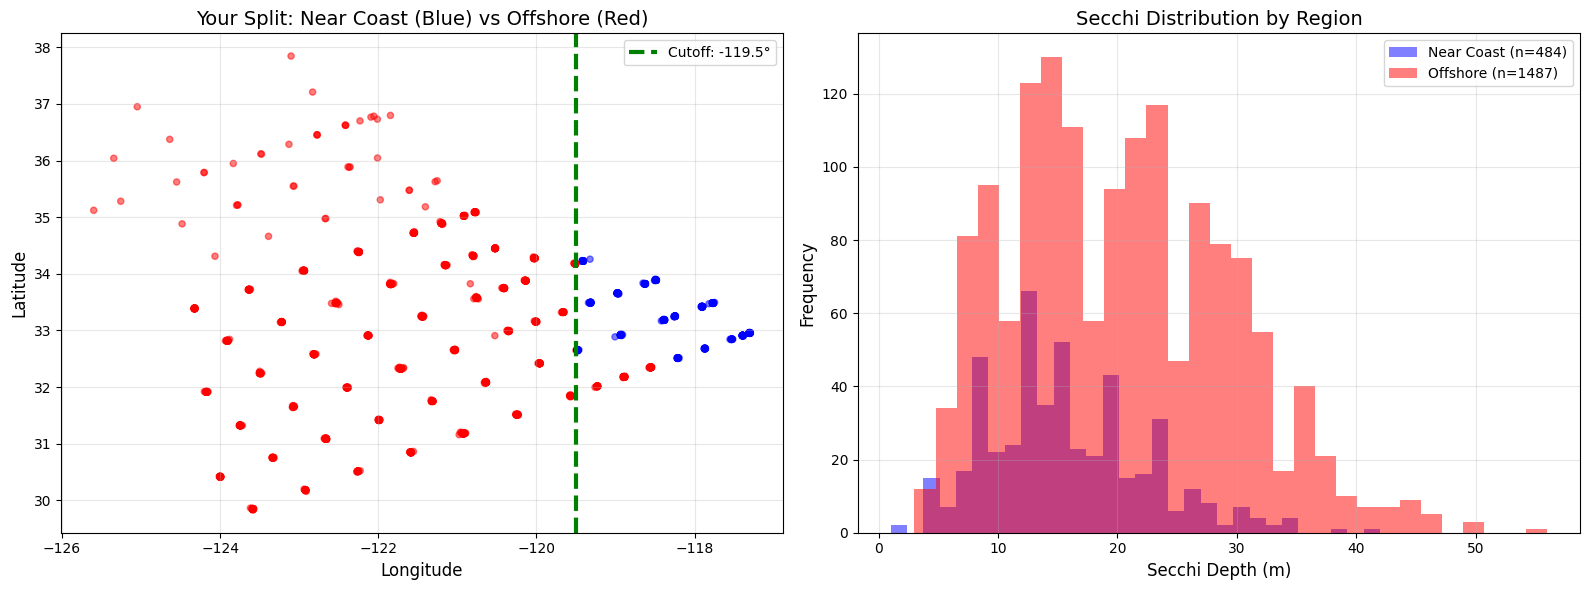


STATISTICAL VALIDATION

Secchi Depth Comparison:
  Near Coast - Mean: 15.74m, Std: 6.65m
  Offshore   - Mean: 20.22m, Std: 9.07m
  Difference: 4.49m
  T-test: t=-10.0320, p=3.9209e-23
  ✓ SIGNIFICANT difference (p < 0.05) - Your split makes sense!

Other feature comparisons:
  K_PAR: ✓ p=0.0233
  XMISS_SUMMED: ✗ p=0.2958
  CHL_A_SUMMED: ✓ p=0.0376

2/4 features show significant differences

Dataset with coastal split saved to: ../results/data_with_coastal_split.csv

NEXT STEPS:
1. Review the plots above
2. If you're happy with the split, proceed to train regional models
3. If not, edit LONGITUDE_CUTOFF in the script and re-run


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.spatial.distance import cdist

# ============================================================================
# LOAD DATA
# ============================================================================

print("Loading data...")
df = enhanced_df.copy()

# Remove rows with missing Lat/Lon or Secchi
df = df[df['Lat_Dec'].notna() & df['Lon_Dec'].notna() & df['Secchi'].notna()].copy()

print(f"Total observations with valid coordinates: {len(df)}")

results_dir = Path("../results")
results_dir.mkdir(exist_ok=True)

# ============================================================================
# EXPLORATORY SPATIAL VISUALIZATION
# ============================================================================

print("\n" + "="*80)
print("EXPLORATORY SPATIAL ANALYSIS")
print("="*80)

# Create comprehensive spatial plots
fig = plt.figure(figsize=(20, 12))

# Plot 1: Simple scatter - see the sampling pattern
ax1 = plt.subplot(2, 3, 1)
ax1.scatter(df['Lon_Dec'], df['Lat_Dec'], alpha=0.3, s=10, c='blue')
ax1.set_xlabel('Longitude', fontsize=11)
ax1.set_ylabel('Latitude', fontsize=11)
ax1.set_title(f'All Sampling Locations (n={len(df)})', fontsize=12)
ax1.grid(True, alpha=0.3)

# Plot 2: Colored by Secchi depth
ax2 = plt.subplot(2, 3, 2)
scatter2 = ax2.scatter(df['Lon_Dec'], df['Lat_Dec'], 
                       c=df['Secchi'], cmap='viridis', 
                       alpha=0.6, s=20, vmin=0, vmax=df['Secchi'].quantile(0.95))
ax2.set_xlabel('Longitude', fontsize=11)
ax2.set_ylabel('Latitude', fontsize=11)
ax2.set_title('Colored by Secchi Depth', fontsize=12)
ax2.grid(True, alpha=0.3)
plt.colorbar(scatter2, ax=ax2, label='Secchi (m)')

# Plot 3: Longitude distribution
ax3 = plt.subplot(2, 3, 3)
ax3.hist(df['Lon_Dec'], bins=50, edgecolor='black', alpha=0.7)
ax3.set_xlabel('Longitude', fontsize=11)
ax3.set_ylabel('Frequency', fontsize=11)
ax3.set_title('Longitude Distribution', fontsize=12)
ax3.grid(True, alpha=0.3)
# Add vertical lines at potential cutoffs
for lon in [-121, -120, -119, -118]:
    ax3.axvline(lon, color='red', linestyle='--', alpha=0.5, linewidth=1)

# Plot 4: Latitude distribution
ax4 = plt.subplot(2, 3, 4)
ax4.hist(df['Lat_Dec'], bins=50, edgecolor='black', alpha=0.7)
ax4.set_xlabel('Latitude', fontsize=11)
ax4.set_ylabel('Frequency', fontsize=11)
ax4.set_title('Latitude Distribution', fontsize=12)
ax4.grid(True, alpha=0.3)

# Plot 5: Colored by K_PAR (if available)
ax5 = plt.subplot(2, 3, 5)
if 'CHL_A_SUMMED' in df.columns and df['CHL_A_SUMMED'].notna().sum() > 0:
    scatter5 = ax5.scatter(df['Lon_Dec'], df['Lat_Dec'], 
                          c=df['CHL_A_SUMMED'], cmap='plasma', 
                          alpha=0.6, s=20, vmin=0, vmax=df['CHL_A_SUMMED'].quantile(0.95))
    ax5.set_xlabel('Longitude', fontsize=11)
    ax5.set_ylabel('Latitude', fontsize=11)
    ax5.set_title('Colored by CHL_A_SUMMED', fontsize=12)
    ax5.grid(True, alpha=0.3)
    plt.colorbar(scatter5, ax=ax5, label='CHL_A_SUMMED')
else:
    ax5.text(0.5, 0.5, 'CHL_A_SUMMED not available', ha='center', va='center', fontsize=12)
    ax5.axis('off')

# Plot 6: Distance from coast (approximate)
ax6 = plt.subplot(2, 3, 6)
# Approximate coast longitude (California coast is around -120 to -117)
df['APPROX_DIST_FROM_COAST'] = np.abs(df['Lon_Dec'] + 120)
scatter6 = ax6.scatter(df['Lon_Dec'], df['Lat_Dec'], 
                      c=df['APPROX_DIST_FROM_COAST'], cmap='RdYlBu_r', 
                      alpha=0.6, s=20)
ax6.set_xlabel('Longitude', fontsize=11)
ax6.set_ylabel('Latitude', fontsize=11)
ax6.set_title('Approximate Distance from Coast (longitude-based)', fontsize=12)
ax6.grid(True, alpha=0.3)
plt.colorbar(scatter6, ax=ax6, label='Distance proxy')

plt.tight_layout()
plt.savefig(results_dir / "spatial_exploration.png", dpi=300, bbox_inches='tight')
print(f"Saved: {results_dir / 'spatial_exploration.png'}")
plt.show()

# ============================================================================
# SECCHI ANALYSIS BY LONGITUDE/LATITUDE BINS
# ============================================================================

print("\n" + "="*80)
print("SECCHI PATTERNS BY LOCATION")
print("="*80)

# Create longitude bins
df['LON_BIN'] = pd.cut(df['Lon_Dec'], bins=10)

# Calculate mean Secchi per longitude bin
lon_bin_stats = df.groupby('LON_BIN').agg({
    'Secchi': ['mean', 'std', 'count'],
    'K_PAR': 'mean' if 'K_PAR' in df.columns else lambda x: np.nan
}).reset_index()

print("\nSecchi statistics by Longitude bins:")
print(lon_bin_stats)

# Plot Secchi vs Longitude
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot 1: Scatter Secchi vs Longitude
axes[0, 0].scatter(df['Lon_Dec'], df['Secchi'], alpha=0.3, s=10)
axes[0, 0].set_xlabel('Longitude', fontsize=12)
axes[0, 0].set_ylabel('Secchi Depth (m)', fontsize=12)
axes[0, 0].set_title('Secchi vs Longitude', fontsize=13)
axes[0, 0].grid(True, alpha=0.3)
# Add vertical lines at potential cutoffs
for lon in [-121, -120, -119, -118]:
    axes[0, 0].axvline(lon, color='red', linestyle='--', alpha=0.5, linewidth=1)
    axes[0, 0].text(lon, axes[0, 0].get_ylim()[1]*0.95, f'{lon}°', 
                   ha='center', fontsize=9, color='red')

# Plot 2: Scatter Secchi vs Latitude
axes[0, 1].scatter(df['Lat_Dec'], df['Secchi'], alpha=0.3, s=10)
axes[0, 1].set_xlabel('Latitude', fontsize=12)
axes[0, 1].set_ylabel('Secchi Depth (m)', fontsize=12)
axes[0, 1].set_title('Secchi vs Latitude', fontsize=13)
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: K_PAR vs Longitude (if available)
if 'CHL_A_SUMMED' in df.columns and df['CHL_A_SUMMED'].notna().sum() > 0:
    axes[1, 0].scatter(df['Lon_Dec'], df['CHL_A_SUMMED'], alpha=0.3, s=10, color='orange')
    axes[1, 0].set_xlabel('Longitude', fontsize=12)
    axes[1, 0].set_ylabel('CHL_A_SUMMED', fontsize=12)
    axes[1, 0].set_title('CHL_A_SUMMED vs Longitude', fontsize=13)
    axes[1, 0].grid(True, alpha=0.3)
    for lon in [-121, -120, -119, -118]:
        axes[1, 0].axvline(lon, color='red', linestyle='--', alpha=0.5, linewidth=1)
else:
    axes[1, 0].text(0.5, 0.5, 'CHL_A_SUMMED not available', ha='center', va='center')
    axes[1, 0].axis('off')

# Plot 4: Hexbin density plot
axes[1, 1].hexbin(df['Lon_Dec'], df['Lat_Dec'], gridsize=30, cmap='Blues', mincnt=1)
axes[1, 1].set_xlabel('Longitude', fontsize=12)
axes[1, 1].set_ylabel('Latitude', fontsize=12)
axes[1, 1].set_title('Sampling Density', fontsize=13)

plt.tight_layout()
plt.savefig(results_dir / "secchi_by_location.png", dpi=300, bbox_inches='tight')
print(f"Saved: {results_dir / 'secchi_by_location.png'}")
plt.show()

# ============================================================================
# INTERACTIVE: HELP DEFINE COASTAL BOUNDARY
# ============================================================================

print("\n" + "="*80)
print("DEFINE YOUR COASTAL/OFFSHORE BOUNDARY")
print("="*80)

print("\nBased on the visualizations above, define your boundary:")
print("\nOption 1: Use LONGITUDE cutoff")
print("  Example: Lon_Dec > -119.5 = Near Coast, Lon_Dec <= -119.5 = Offshore")
print("\nOption 2: Use DISTANCE FROM COAST")
print("  Example: Distance < 50km = Near Coast")
print("\nOption 3: Use COMBINED (Longitude AND Latitude)")
print("  Example: Complex polygonal boundary")

print("\n" + "="*80)
print("SUGGESTED CUTOFFS (based on your data):")
print("="*80)

# Suggest potential cutoffs based on data distribution
lon_median = df['Lon_Dec'].median()
lon_q33 = df['Lon_Dec'].quantile(0.33)
lon_q67 = df['Lon_Dec'].quantile(0.67)

print(f"\nLongitude statistics:")
print(f"  Minimum:  {df['Lon_Dec'].min():.2f}°")
print(f"  33rd %ile: {lon_q33:.2f}° (1/3 of data more west)")
print(f"  Median:    {lon_median:.2f}° (50/50 split)")
print(f"  67th %ile: {lon_q67:.2f}° (1/3 of data more east)")
print(f"  Maximum:  {df['Lon_Dec'].max():.2f}°")

print(f"\nPotential cutoff options:")
print(f"  Conservative (close to coast): Lon > -119.0")
print(f"  Moderate (balanced):           Lon > {lon_median:.1f}")
print(f"  Liberal (far from coast):      Lon > {lon_q67:.1f}")

# ============================================================================
# NOW YOU DECIDE - ENTER YOUR CUTOFF HERE
# ============================================================================

print("\n" + "="*80)
print("ENTER YOUR DECISION:")
print("="*80)

# EDIT THIS SECTION AFTER VIEWING THE PLOTS
# ========================================

# OPTION 1: Longitude-based (most common)
LONGITUDE_CUTOFF = -119.5  # EDIT THIS VALUE based on your plots

df['NEAR_COAST'] = df['Lon_Dec'] > LONGITUDE_CUTOFF

# OPTION 2: Distance-based (uncomment if you prefer)
DISTANCE_CUTOFF_KM = 50  # km from coast
DISTANCE_CUTOFF_DEG = DISTANCE_CUTOFF_KM / 111  # rough conversion
df['NEAR_COAST'] = df['APPROX_DIST_FROM_COAST'] < DISTANCE_CUTOFF_DEG

# OPTION 3: Combined criteria (uncomment if you prefer)
df['NEAR_COAST'] = (df['Lon_Dec'] > -119.5) & (df['Lat_Dec'] > 32.5)

# ========================================

near_coast_count = df['NEAR_COAST'].sum()
offshore_count = (~df['NEAR_COAST']).sum()

print(f"\nYour split:")
print(f"  Near Coast: {near_coast_count} observations ({near_coast_count/len(df)*100:.1f}%)")
print(f"  Offshore:   {offshore_count} observations ({offshore_count/len(df)*100:.1f}%)")

# ============================================================================
# VISUALIZE YOUR SPLIT
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Show the split
colors = ['blue' if x else 'red' for x in df['NEAR_COAST']]
axes[0].scatter(df['Lon_Dec'], df['Lat_Dec'], c=colors, alpha=0.5, s=20)
axes[0].axvline(LONGITUDE_CUTOFF, color='green', linestyle='--', linewidth=3, 
               label=f'Cutoff: {LONGITUDE_CUTOFF}°')
axes[0].set_xlabel('Longitude', fontsize=12)
axes[0].set_ylabel('Latitude', fontsize=12)
axes[0].set_title(f'Your Split: Near Coast (Blue) vs Offshore (Red)', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Secchi distribution by region
near_coast_secchi = df[df['NEAR_COAST']]['Secchi']
offshore_secchi = df[~df['NEAR_COAST']]['Secchi']

axes[1].hist(near_coast_secchi, bins=30, alpha=0.5, label=f'Near Coast (n={near_coast_count})', color='blue')
axes[1].hist(offshore_secchi, bins=30, alpha=0.5, label=f'Offshore (n={offshore_count})', color='red')
axes[1].set_xlabel('Secchi Depth (m)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Secchi Distribution by Region', fontsize=14)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(results_dir / "your_coastal_split.png", dpi=300, bbox_inches='tight')
print(f"\nSaved: {results_dir / 'your_coastal_split.png'}")
plt.show()

# ============================================================================
# STATISTICAL VALIDATION OF YOUR SPLIT
# ============================================================================

from scipy import stats as scipy_stats

print("\n" + "="*80)
print("STATISTICAL VALIDATION")
print("="*80)

# T-test for Secchi
t_stat, p_value = scipy_stats.ttest_ind(near_coast_secchi.dropna(), 
                                        offshore_secchi.dropna())

print(f"\nSecchi Depth Comparison:")
print(f"  Near Coast - Mean: {near_coast_secchi.mean():.2f}m, Std: {near_coast_secchi.std():.2f}m")
print(f"  Offshore   - Mean: {offshore_secchi.mean():.2f}m, Std: {offshore_secchi.std():.2f}m")
print(f"  Difference: {abs(near_coast_secchi.mean() - offshore_secchi.mean()):.2f}m")
print(f"  T-test: t={t_stat:.4f}, p={p_value:.4e}")

if p_value < 0.05:
    print(f"  ✓ SIGNIFICANT difference (p < 0.05) - Your split makes sense!")
else:
    print(f"  ✗ NO significant difference (p >= 0.05) - Consider adjusting cutoff")

# Test other features
features_to_test = ['K_PAR', 'XMISS_SUMMED', 'CHL_A_SUMMED', 'PHAEO_SUMMED']
sig_count = 0

print(f"\nOther feature comparisons:")
for feature in features_to_test:
    if feature in df.columns and df[feature].notna().sum() > 10:
        near = df[df['NEAR_COAST']][feature].dropna()
        off = df[~df['NEAR_COAST']][feature].dropna()
        
        if len(near) > 0 and len(off) > 0:
            t_stat, p_val = scipy_stats.ttest_ind(near, off)
            sig = '✓' if p_val < 0.05 else '✗'
            if p_val < 0.05:
                sig_count += 1
            print(f"  {feature}: {sig} p={p_val:.4f}")

print(f"\n{sig_count}/{len(features_to_test)} features show significant differences")

# ============================================================================
# SAVE YOUR SPLIT FOR MODELING
# ============================================================================

# Save the dataset with your coastal classification
output_path = results_dir / "data_with_coastal_split.csv"
df.to_csv(output_path, index=False)
print(f"\nDataset with coastal split saved to: {output_path}")

print("\n" + "="*80)
print("NEXT STEPS:")
print("="*80)
print("1. Review the plots above")
print("2. If you're happy with the split, proceed to train regional models")
print("3. If not, edit LONGITUDE_CUTOFF in the script and re-run")
print("="*80)